# Header

**NB:** You need 120g to run this entire notebook!

In [2]:
import os
from scipy import signal, stats
import numpy as np

# os.environ["MODIN_ENGINE"] = "ray"  # Modin will use Ray
# import modin.pandas as pd
import pandas as pd

import bisect
import importlib
import warnings
from pathlib import Path
import gc

# from tqdm.notebook import trange, tqdm
# # Create new `pandas` methods which use `tqdm` progress
# tqdm.pandas()

import ete3
np.random.seed(7)

# import psutil, os
# def mem():
#     return psutil.Process(os.getpid()).memory_info().rss / 1024**3

Plotting setup:

In [3]:
%matplotlib inline

# Make inline plots vector graphics instead of raster graphics
from matplotlib_inline.backend_inline import set_matplotlib_formats
#set_matplotlib_formats('pdf', 'svg')
set_matplotlib_formats('retina', 'png')

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

#matplotlib.rcParams['figure.figsize'] = (20.0, 10.0)

# import mpld3

import seaborn as sns
sns.set() # sets seaborn default "prettyness:
sns.set_style("white")
sns.set_context("notebook")

# lowess for plotting
from statsmodels.nonparametric.smoothers_lowess import lowess

# My own paired palette replacing the last brown pair with violets
sns.color_palette('Paired').as_hex()
Paired = sns.color_palette(['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c',
                            '#fdbf6f', '#ff7f00', '#cab2d6','#6a3d9a', '#e585cf', '#ad009d'])
#sns.palplot(Paired)

from shared_vars_and_func import *

Monospace font for numbers in tables:

In [4]:
%%html
<style> table { font-variant-numeric: tabular-nums; } </style>

In [5]:
remapped_data_path = Path('../data/composition_cpg_remapped')

## Load species details

In [6]:
species_details = pd.read_csv('../data/species_details.txt', sep='\t')
with pd.option_context('display.max_rows', None): 
    display(species_details.sort_values(by='species'))
#species_details.head()

,species2014,species,english,latin,group,family,male_min,male_max,female_min,female_max,weight,order,order2014,branch_length
14,ACACH,ACACH,Rifleman,Acanthisitta chloris,finch,wrens,"6,00","6,00","7,00","7,00","6,5",44,15,0.083568
45,ANAPL,ANAPL,Mallard,Anas platyrhynchos,chicken,waterfowl,"870,00","1800,00","735,00","1320,00","1181,25",3,46,0.100287
3,APAVI,APAVI,Bar-tailed Trogon,Apaloderma vittatum,woodpecker,trogons,"55,00","55,00","55,00","55,00",55,36,4,0.104832
24,APTFO,APTFO,Emperor Penguin,Aptenodytes forsteri,penguin,penguins,"19000,00","46000,00","19000,00","46000,00",32500,24,25,0.010910
30,BALRE,BALRE,Grey Crowned Crane,Balearica regulorum,crane,cranes,"3000,00","4000,00","3000,00","4000,00",3500,18,31,0.057056
2,BUCRH,BUCRH,Rhinoceros Hornbill,Buceros rhinoceros,woodpecker,hornbills,"2465,00","2960,00","2040,00","2330,00","2448,75",37,3,0.099782
36,CALAN,CALAN,Annas Hummingbird,Calypte anna,swift,hummingbirds,"3,30","5,80","3,30","4,60","4,25",16,37,0.112564
37,ANTCA,CAPCA,Chuck-wills-widow,Antrostomus carolinensis,swift,nightjars,"94,00","137,00","114,00","120,00","116,25",14,38,0.069661
18,CARCR,CARCR,Red-legged Seriema,Cariama cristata,finch,seriemas,"1500,00","1500,00","1500,00","1500,00",1500,40,19,0.055002
9,CATAU,CATAU,Turkey Vulture,Cathartes aura,woodpecker,vultures,"850,00","2000,00","850,00","2000,00",1425,30,10,0.030070


In [7]:
species_details = pd.read_csv('../data/species_details.txt', sep='\t')
with pd.option_context('display.max_rows', None): 
    print(species_details[['species', 'species2014', 'english', 'latin']].sort_values(by='species'))
#species_details.head()

   species species2014                     english                     latin
14   ACACH       ACACH                    Rifleman      Acanthisitta chloris
45   ANAPL       ANAPL                     Mallard        Anas platyrhynchos
3    APAVI       APAVI           Bar-tailed Trogon       Apaloderma vittatum
24   APTFO       APTFO             Emperor Penguin      Aptenodytes forsteri
30   BALRE       BALRE          Grey Crowned Crane       Balearica regulorum
2    BUCRH       BUCRH         Rhinoceros Hornbill        Buceros rhinoceros
36   CALAN       CALAN           Annas Hummingbird              Calypte anna
37   CAPCA       ANTCA           Chuck-wills-widow  Antrostomus carolinensis
18   CARCR       CARCR          Red-legged Seriema          Cariama cristata
9    CATAU       CATAU              Turkey Vulture            Cathartes aura
35   CHAPE       CHAPE               Chimney Swift         Chaetura pelagica
29   CHAVO       CHAVO                    Killdeer      Charadrius vociferus

# CGI data

In [8]:
cgi = pd.read_csv('../data/bed/CGI-taeGut1.txt', sep='\t')
cgi['pos'] = (cgi.start + (cgi.end - cgi.start) / 2).round().astype(int)
cgi['chrom'] = cgi['chr'].str.replace('chr', '')
cgi.head()

,chr,start,end,length,CpGcount,GCcount,pctGC,obsExp,pos,chrom
0,chr1,21810,21940,131,9,83,0.633588,0.685465,21875,1
1,chr1,31020,31136,117,15,82,0.700855,1.054054,31078,1
2,chr1,32772,33056,285,23,202,0.708772,0.642584,32914,1
3,chr1,47794,48027,234,12,130,0.555556,0.668571,47910,1
4,chr1,108367,108549,183,9,93,0.508197,0.772514,108458,1


# Find size order of TAEGU chromosomes

In [8]:
from Bio import SeqIO
import gzip

records = []
with gzip.open('../../../../data/assembly/Taeniopygia_guttata.fa.gz', 'rt') as f:
    for record in SeqIO.parse(f, "fasta"):
        if record.id in chromosomes:
            records.append([record.id, len(record)])
taegu_chromosome_sizes = (pd.DataFrame()
                          .from_records(records, columns=['chrom', 'chrom_size'])
                          .sort_values(by='chrom_size', ascending=False)
                         )
taegu_chromosome_sizes

,chrom,chrom_size
15,2,156412533
14,1,118548696
13,3,112617285
12,1A,73657157
11,4,69780378
10,5,62374962
9,7,39844632
8,6,36305782
7,9,27241186
6,12,21576510


In [9]:
taegu_chromosome_sizes.to_hdf('../results/taegu_chromosome_sizes.h5', key='df', format='table')

# Hotspot data

In [10]:
hotspots = pd.read_csv('../data/bed/hotspots.bed', names=['chrom', 'start', 'end'], sep='\t')
hotspots['pos'] = (hotspots.start + (hotspots.end - hotspots.start) / 2).round().astype(int)
hotspots['chrom'] = hotspots.chrom.str.replace('chr', '')
hotspots.rename(columns={'stop': 'end'}, inplace=True)
hotspots.head()

,chrom,start,end,pos
0,1,6892116,6896116,6894116
1,1,8803005,8807005,8805005
2,1,9684030,9690030,9687030
3,1,10395061,10399061,10397061
4,1,10500751,10506751,10503751


In [11]:
hotspots.pos.unique().size

2856

Function for reducing memory of data frames:

# Data mapped relative to hotspots (hotspot_data)

In [12]:
branch_lengths = pd.read_hdf('../results/branch_lengths.h5')

All 1kb windows overlapping hotspot center are set to zero distance. For all other windows, the distance is the distane to the closest hotspot center.

In [13]:
df_list = list()
for path in remapped_data_path.iterdir():
    if path.name.endswith('.hotspot_relative.txt'):
        df = pd.read_csv(str(path), sep='\t', low_memory=False)
        df_list.append(df)
hotspot_table = pd.concat(df_list, sort=True).merge(branch_lengths, on=['species', 'ancestor'], how='left')

In [14]:
hotspot_table.to_hdf('../results/hotspot_table.h5', key='df', format='table')

In [15]:
del df_list
gc.collect()

85

Optimize data frame. Exclude one of the eagles. We also exclude windows smaller than 1000. These are split windows overlapping midpoint between two hotspots. 

In [16]:
def data_filter(df):
    include_species = ~df.species.isin(['HALAL'])
    win_size = (df.end - df.start).abs()
    include_window = (win_size == 1000) | (win_size == 0)
    return include_species & include_window

hotspot_data = optimize_data_frame(hotspot_table).loc[data_filter]
hotspot_data['species'] = hotspot_data['species'].cat.remove_unused_categories()

In [17]:
len(hotspot_table.start_prox.unique())

2856

In [18]:
del hotspot_table
gc.collect()

31

In [19]:
hotspot_data['hotspot_center'] = (hotspot_data.start_prox + (hotspot_data.end_prox - hotspot_data.start_prox) / 2).astype('int32')

Add species names:

In [20]:
hotspot_data['species_code'] = hotspot_data.species
name_mapping = dict(zip(species_details.species2014, species_details.english))
hotspot_data['species'] = [name_mapping[x] for x in hotspot_data.species_code]

hotspot_data['species'] = hotspot_data['species'].astype('category')

Compute the number of aligned bases in each window:

In [21]:
hotspot_data['nr_aligned'] = hotspot_data[base_counts].sum(axis=1)

Compute substitution rates across each external branch by dividing substitution counts by the ancestral count of the base substituted from:

In [22]:
for subst in substitution_counts + cpg_substitution_counts:
    from_base, to_base = subst[1], subst[3]
    
    adding_subst = [x for x in substitution_counts if x[3] == from_base]
    removing_subst = [x for x in substitution_counts if x[1] == from_base]
    
    hotspot_data[subst.replace('n', 'r')] = hotspot_data[subst] / \
        (hotspot_data['n' + from_base] - hotspot_data[adding_subst].sum(axis=1) + hotspot_data[removing_subst].sum(axis=1))

In [23]:
hotspot_data.head()

,ancestor,bin,chrom,end,end_orig,end_prox,nA,nA2C,nA2G,nA2T,...,rA2c,rA2g,rc2A,rc2g,rc2T,rg2A,rg2c,rg2T,rT2c,rT2g
0,Anc44,0.0,1,0,6895000,6894116,94,2,3,1,...,0.010204,0.020408,0.0,0.000000,0.090909,0.090909,0.0,0.000000,0.009709,0.009709
1,Anc44,0.0,1,0,8806000,8805005,295,1,6,2,...,0.000000,0.003390,0.0,0.058824,0.058824,0.000000,0.0,0.000000,0.003690,0.000000
2,Anc44,0.0,1,0,9688000,9687030,291,2,4,1,...,0.000000,0.003436,0.0,0.000000,0.666667,0.666667,0.0,0.000000,0.000000,0.000000
3,Anc44,0.0,1,0,10398000,10397061,261,3,6,2,...,0.000000,0.015326,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,Anc44,0.0,1,0,10504000,10503751,113,0,1,2,...,0.000000,0.000000,0.0,0.000000,0.064516,0.064516,0.0,0.064516,0.000000,0.000000


In [24]:
# for subst in substitution_counts:
#     from_base, to_base = subst[1], subst[3]
    
#     adding_subst = [x for x in substitution_counts if x[3] == from_base]
#     removing_subst = [x for x in substitution_counts if x[1] == from_base]
    
#     hotspot_data[subst.replace('n', 'r')] = hotspot_data[subst] / \
#         (hotspot_data['n' + from_base] - hotspot_data[adding_subst].sum(axis=1) + hotspot_data[removing_subst].sum(axis=1))

Normalize so rates are relative to so they are relative to the 30kb - 40kb flanks:

In [25]:
# flank_rates = (hotspot_data.loc[(hotspot_data.bin.abs() > flank_start) & (hotspot_data.bin.abs() <= 40000)]
#                .groupby(['species_code'], observed=False)
#                [all_substitutions]
#                .mean()
#               )
# df = hotspot_data.merge(flank_rates, on='species_code', how='left', suffixes=('_raw', '_flank_mean'))
# for pattern in all_substitutions:
#     hotspot_data[pattern] = df[pattern + '_raw'] /  df[pattern + '_flank_mean']

In [26]:
len(hotspot_data.species.unique())

47

In [27]:
hotspot_data.head()

,ancestor,bin,chrom,end,end_orig,end_prox,nA,nA2C,nA2G,nA2T,...,rA2c,rA2g,rc2A,rc2g,rc2T,rg2A,rg2c,rg2T,rT2c,rT2g
0,Anc44,0.0,1,0,6895000,6894116,94,2,3,1,...,0.010204,0.020408,0.0,0.000000,0.090909,0.090909,0.0,0.000000,0.009709,0.009709
1,Anc44,0.0,1,0,8806000,8805005,295,1,6,2,...,0.000000,0.003390,0.0,0.058824,0.058824,0.000000,0.0,0.000000,0.003690,0.000000
2,Anc44,0.0,1,0,9688000,9687030,291,2,4,1,...,0.000000,0.003436,0.0,0.000000,0.666667,0.666667,0.0,0.000000,0.000000,0.000000
3,Anc44,0.0,1,0,10398000,10397061,261,3,6,2,...,0.000000,0.015326,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,Anc44,0.0,1,0,10504000,10503751,113,0,1,2,...,0.000000,0.000000,0.0,0.000000,0.064516,0.064516,0.0,0.064516,0.000000,0.000000


In [28]:
hotspot_data.to_hdf('../results/hotspot_data.h5', key='df', format='table')

Make a copy of the entire data frame and do the same but including CpG sites:

In [29]:
hotspot_data_incl_cpg = hotspot_data.copy(deep=True)

for subst in substitution_counts:
    from_base, to_base = subst[1], subst[3]
    
    adding_subst = [x for x in substitution_counts+cpg_substitution_counts if x[3].upper() == from_base]
    removing_subst = [x for x in substitution_counts+cpg_substitution_counts if x[1].upper() == from_base]
    
    same_subst = [x for x in substitution_counts+cpg_substitution_counts if x[1:].upper() == subst[1:]]
   
    from_base_count = hotspot_data['n' + from_base]
    if from_base in 'GC':
        from_base_count += hotspot_data['n' + from_base.lower()]

    hotspot_data_incl_cpg[subst.replace('n', 'r')] = hotspot_data[same_subst].sum(axis=1) / \
            (from_base_count - hotspot_data[adding_subst].sum(axis=1) + hotspot_data[removing_subst].sum(axis=1))    

Normalize so rates are relative to so they are relative to the 30kb - 40kb flanks:

In [30]:
# flank_rates_incl_cpg = (hotspot_data_incl_cpg.loc[(hotspot_data_incl_cpg.bin.abs() > flank_start) & (hotspot_data_incl_cpg.bin.abs() <= 40000)]
#                .groupby(['species_code'], observed=False)
#                [all_substitutions]
#                .mean()
#               )
# df = hotspot_data_incl_cpg.merge(flank_rates_incl_cpg, on='species_code', how='left', suffixes=('_raw', '_flank_mean'))
# for pattern in all_substitutions:
#     hotspot_data_incl_cpg[pattern] = df[pattern + '_raw'] /  df[pattern + '_flank_mean']

In [31]:
hotspot_data_incl_cpg.head()

,ancestor,bin,chrom,end,end_orig,end_prox,nA,nA2C,nA2G,nA2T,...,rA2c,rA2g,rc2A,rc2g,rc2T,rg2A,rg2c,rg2T,rT2c,rT2g
0,Anc44,0.0,1,0,6895000,6894116,94,2,3,1,...,0.010204,0.020408,0.0,0.000000,0.090909,0.090909,0.0,0.000000,0.009709,0.009709
1,Anc44,0.0,1,0,8806000,8805005,295,1,6,2,...,0.000000,0.003390,0.0,0.058824,0.058824,0.000000,0.0,0.000000,0.003690,0.000000
2,Anc44,0.0,1,0,9688000,9687030,291,2,4,1,...,0.000000,0.003436,0.0,0.000000,0.666667,0.666667,0.0,0.000000,0.000000,0.000000
3,Anc44,0.0,1,0,10398000,10397061,261,3,6,2,...,0.000000,0.015326,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,Anc44,0.0,1,0,10504000,10503751,113,0,1,2,...,0.000000,0.000000,0.0,0.000000,0.064516,0.064516,0.0,0.064516,0.000000,0.000000


In [32]:
hotspot_data_incl_cpg.to_hdf('../results/hotspot_data_incl_cpg.h5', key='df', format='table')

In [33]:
del hotspot_data
gc.collect()

432

In [34]:
del hotspot_data_incl_cpg
gc.collect()

0

In [35]:
# from Bio import SeqIO
# import gzip
# import re

# df_list = []
# with gzip.open('../../../../data/assembly/Taeniopygia_guttata.fa.gz', 'rt') as f:
#     for record in SeqIO.parse(f, "fasta"):
#         if record.id in chromosomes:
#             seq = str(record.seq)
#             CpG_pos = np.array([m.start() for m in re.finditer('CG', seq)])
#             C_pos = np.array([m.start() for m in re.finditer('C', seq)])
#             G_pos = np.array([m.start() for m in re.finditer('G', seq)])
#             df = pd.DataFrame()
#             df['start'], df['nC'] = np.unique(C_pos // 1000 * 1000, return_counts=True)
            
#             _df = pd.DataFrame()
#             _df['start'], _df['nG'] = np.unique(G_pos // 1000 * 1000, return_counts=True)
#             df = df.merge(_df, how='left')

#             _df = pd.DataFrame()
#             _df['start'], _df['nCpG'] = np.unique(CpG_pos // 1000 * 1000, return_counts=True)
#             df = df.merge(_df, how='left')

#             df['end'] = df.start + 1000
#             df['chrom'] = str(record.id)
            
#             df = df[['chrom', 'start', 'end', 'nC', 'nG', 'nCpG']]
            
#             df_list.append(df)
            
# finch_cpg = pd.concat(df_list)
# finch_cpg['chrom'] = pd.Categorical(finch_cpg['chrom'])
# finch_cpg.head()

# Long format hotspot data (subst_data)

Make a long format data frames with substitution rate data within 40kb from each hotspot:

In [36]:
hotspot_data = pd.read_hdf('../results/hotspot_data.h5')

In [37]:
id_cols = ['species', 'species_code', 'ancestor', 'hotspot_center', 'bin', 'branch_length', 'ultra_branch_length', 'nr_aligned']
subst_data = (hotspot_data
              .loc[lambda df: df.bin.abs() <= 40000, id_cols + all_substitutions + base_counts]
              .melt(id_vars=id_cols,
                    value_vars=all_substitutions,
                    var_name='pattern', value_name='rate')
             )
subst_data['pattern'] = pd.Categorical(subst_data.pattern.values, 
                                       categories=all_substitutions, ordered=True)
subst_data.loc[subst_data.pattern.isin(transitions), 'type'] = 'Transition'
subst_data.loc[~subst_data.pattern.isin(transitions), 'type'] = 'Transversion'
subst_data['type'] = pd.Categorical(subst_data.type.values, categories=['Transition', 'Transversion'], ordered=True)

# scale with flank means
subst_data = (subst_data
 .loc[subst_data.bin.abs() > flank_start]
 .groupby(['species_code', 'pattern'], observed=False)
 .rate
 .mean()
 .reset_index()
 .rename(columns={'rate':'flank_rate'}) 
).merge(subst_data, on=['species_code', 'pattern'], how='right')
subst_data['rate'] /= subst_data['flank_rate']
subst_data.head()

,species_code,pattern,flank_rate,species,ancestor,hotspot_center,bin,branch_length,ultra_branch_length,nr_aligned,rate,type
0,CORBR,rA2C,0.005816,American Crow,Anc44,6894116,0.0,0.038474,0.035454,409,3.508902,Transversion
1,CORBR,rA2C,0.005816,American Crow,Anc44,8805005,0.0,0.038474,0.035454,899,0.582835,Transversion
2,CORBR,rA2C,0.005816,American Crow,Anc44,9687030,0.0,0.038474,0.035454,991,1.181692,Transversion
3,CORBR,rA2C,0.005816,American Crow,Anc44,10397061,0.0,0.038474,0.035454,908,1.976278,Transversion
4,CORBR,rA2C,0.005816,American Crow,Anc44,10503751,0.0,0.038474,0.035454,568,0.000000,Transversion


In [38]:
# (subst_data
#  .loc[subst_data.bin.abs() > flank_start]
#  .groupby(['species_code', 'pattern'], observed=False)
#  .rate
#  .mean()
#  .reset_index()
#  .rename(columns={'rate':'flank_rate'}) 
# ).merge(subst_data, on=['species_code', 'pattern'], how='right')

# (subst_data
#  .rename(columns={'rate':'raw_rate'})
#  .merge(mean_flank_rates, on=['species_code', 'pattern'], how='left')
# )                                                            

In [39]:

# (subst_data
#  .head()
#  .groupby(['species_code', 'pattern'], observed=False)
#  .apply(lambda df: df['rate']/df.loc[subst_data.bin.abs() > flank_start, 'rate'])
#  .reset_index()
# )

-----

## Number of aligned bases and filtering

Distribution of number of aligned bases in windows for TAEGU:

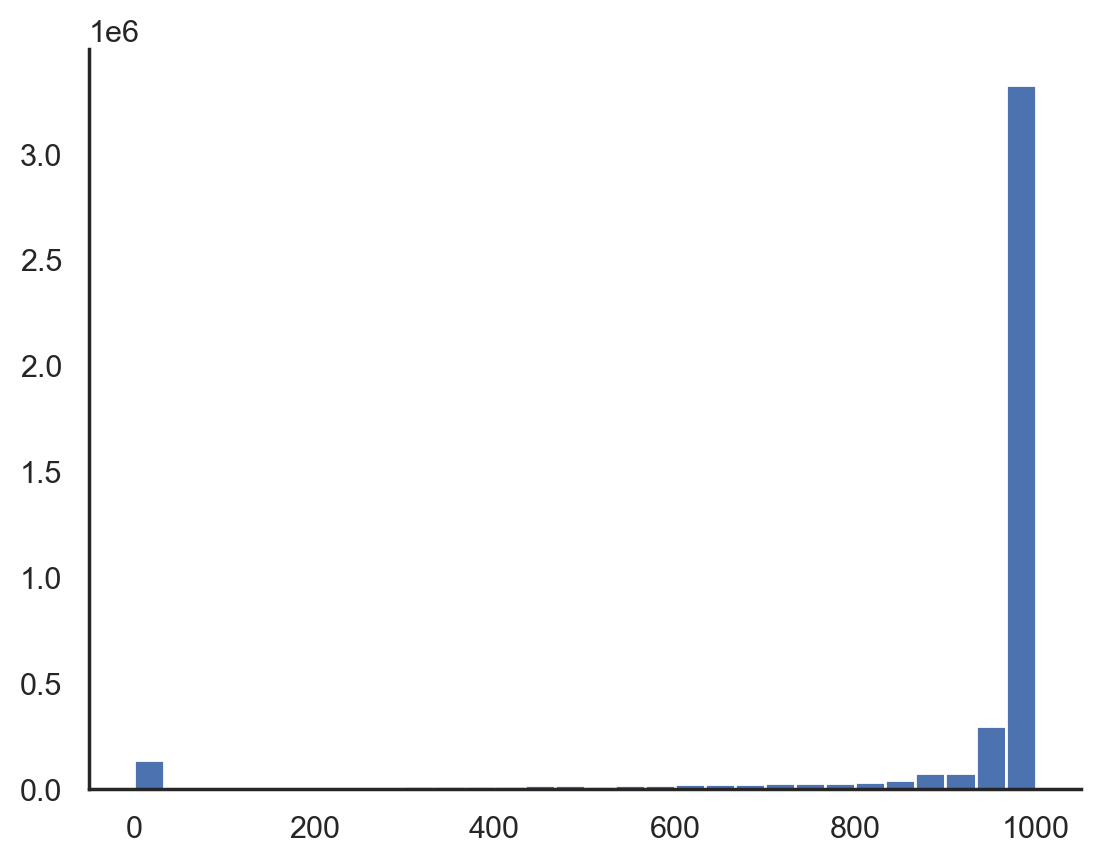

In [40]:
plt.hist(subst_data.loc[subst_data.species_code == 'TAEGU'].nr_aligned, bins=30)
sns.despine()
plt.savefig(figures_path / 'distr_nr_aligned_bases.pdf')

Distribution of number of aligned bases in windows for all others:

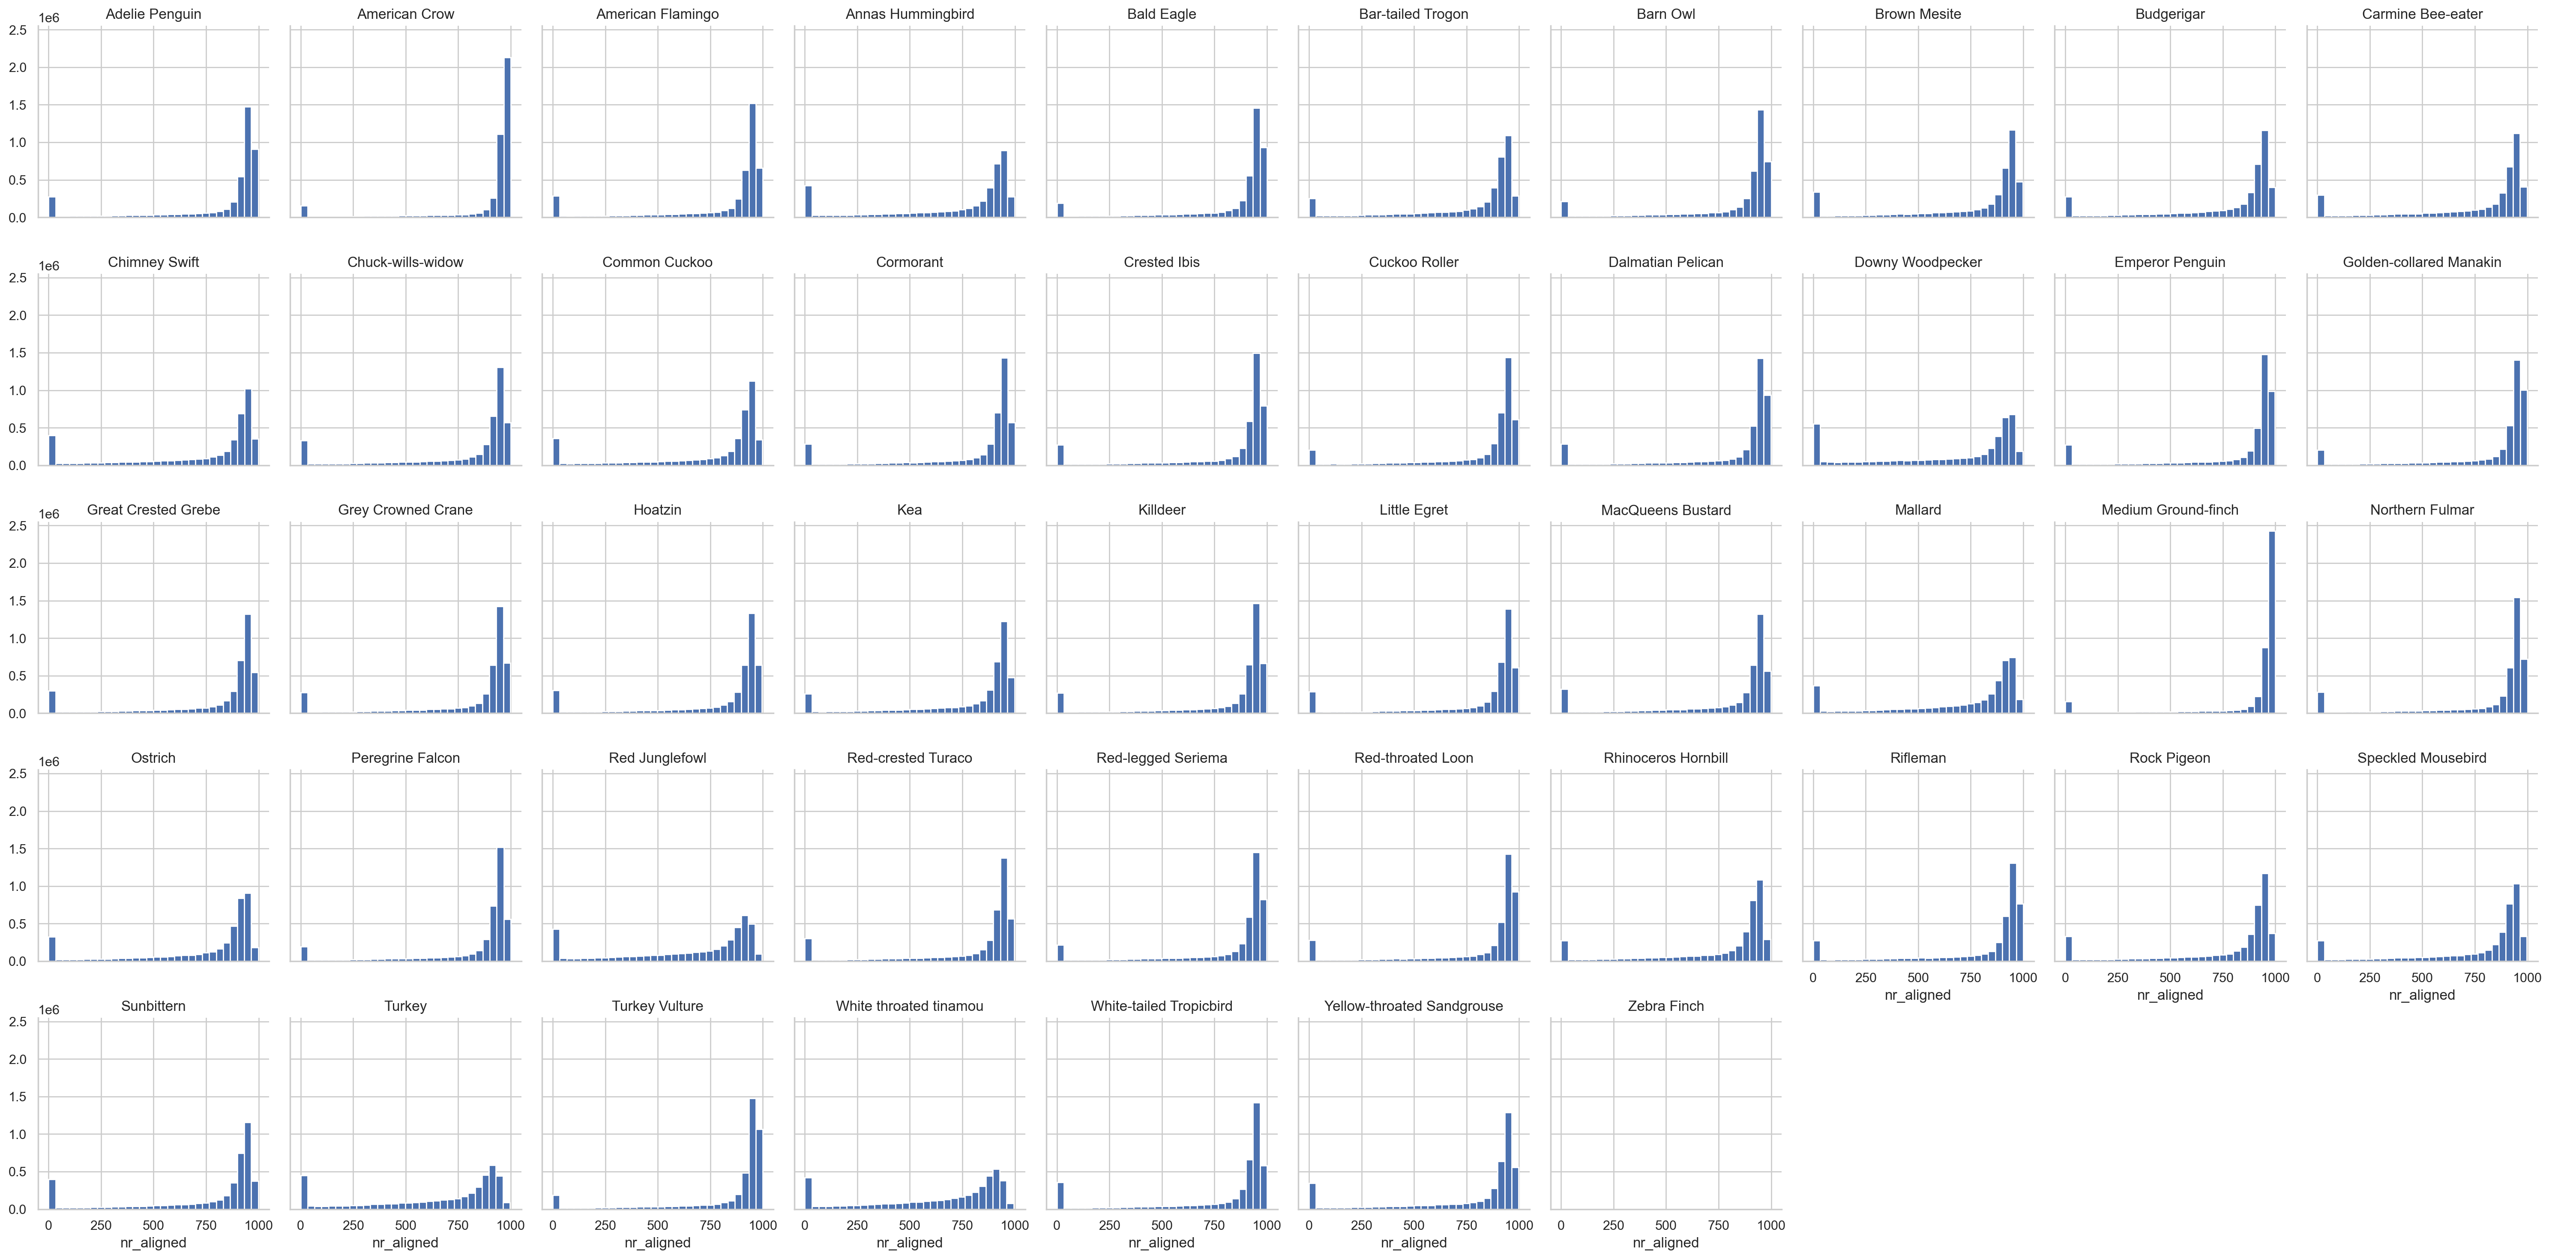

In [41]:
with sns.axes_style('whitegrid'):
    g = sns.FacetGrid(subst_data.loc[subst_data.species_code != 'TAEGU'], col='species', col_wrap=10, sharey=True)
    g.map(plt.hist, 'nr_aligned', bins=30).add_legend()
    g.set_titles(row_template = '{row_name}', col_template = '{col_name}') ;
    plt.savefig(figures_path / 'distr_nr_aligned_bases_indiv_species.pdf')    

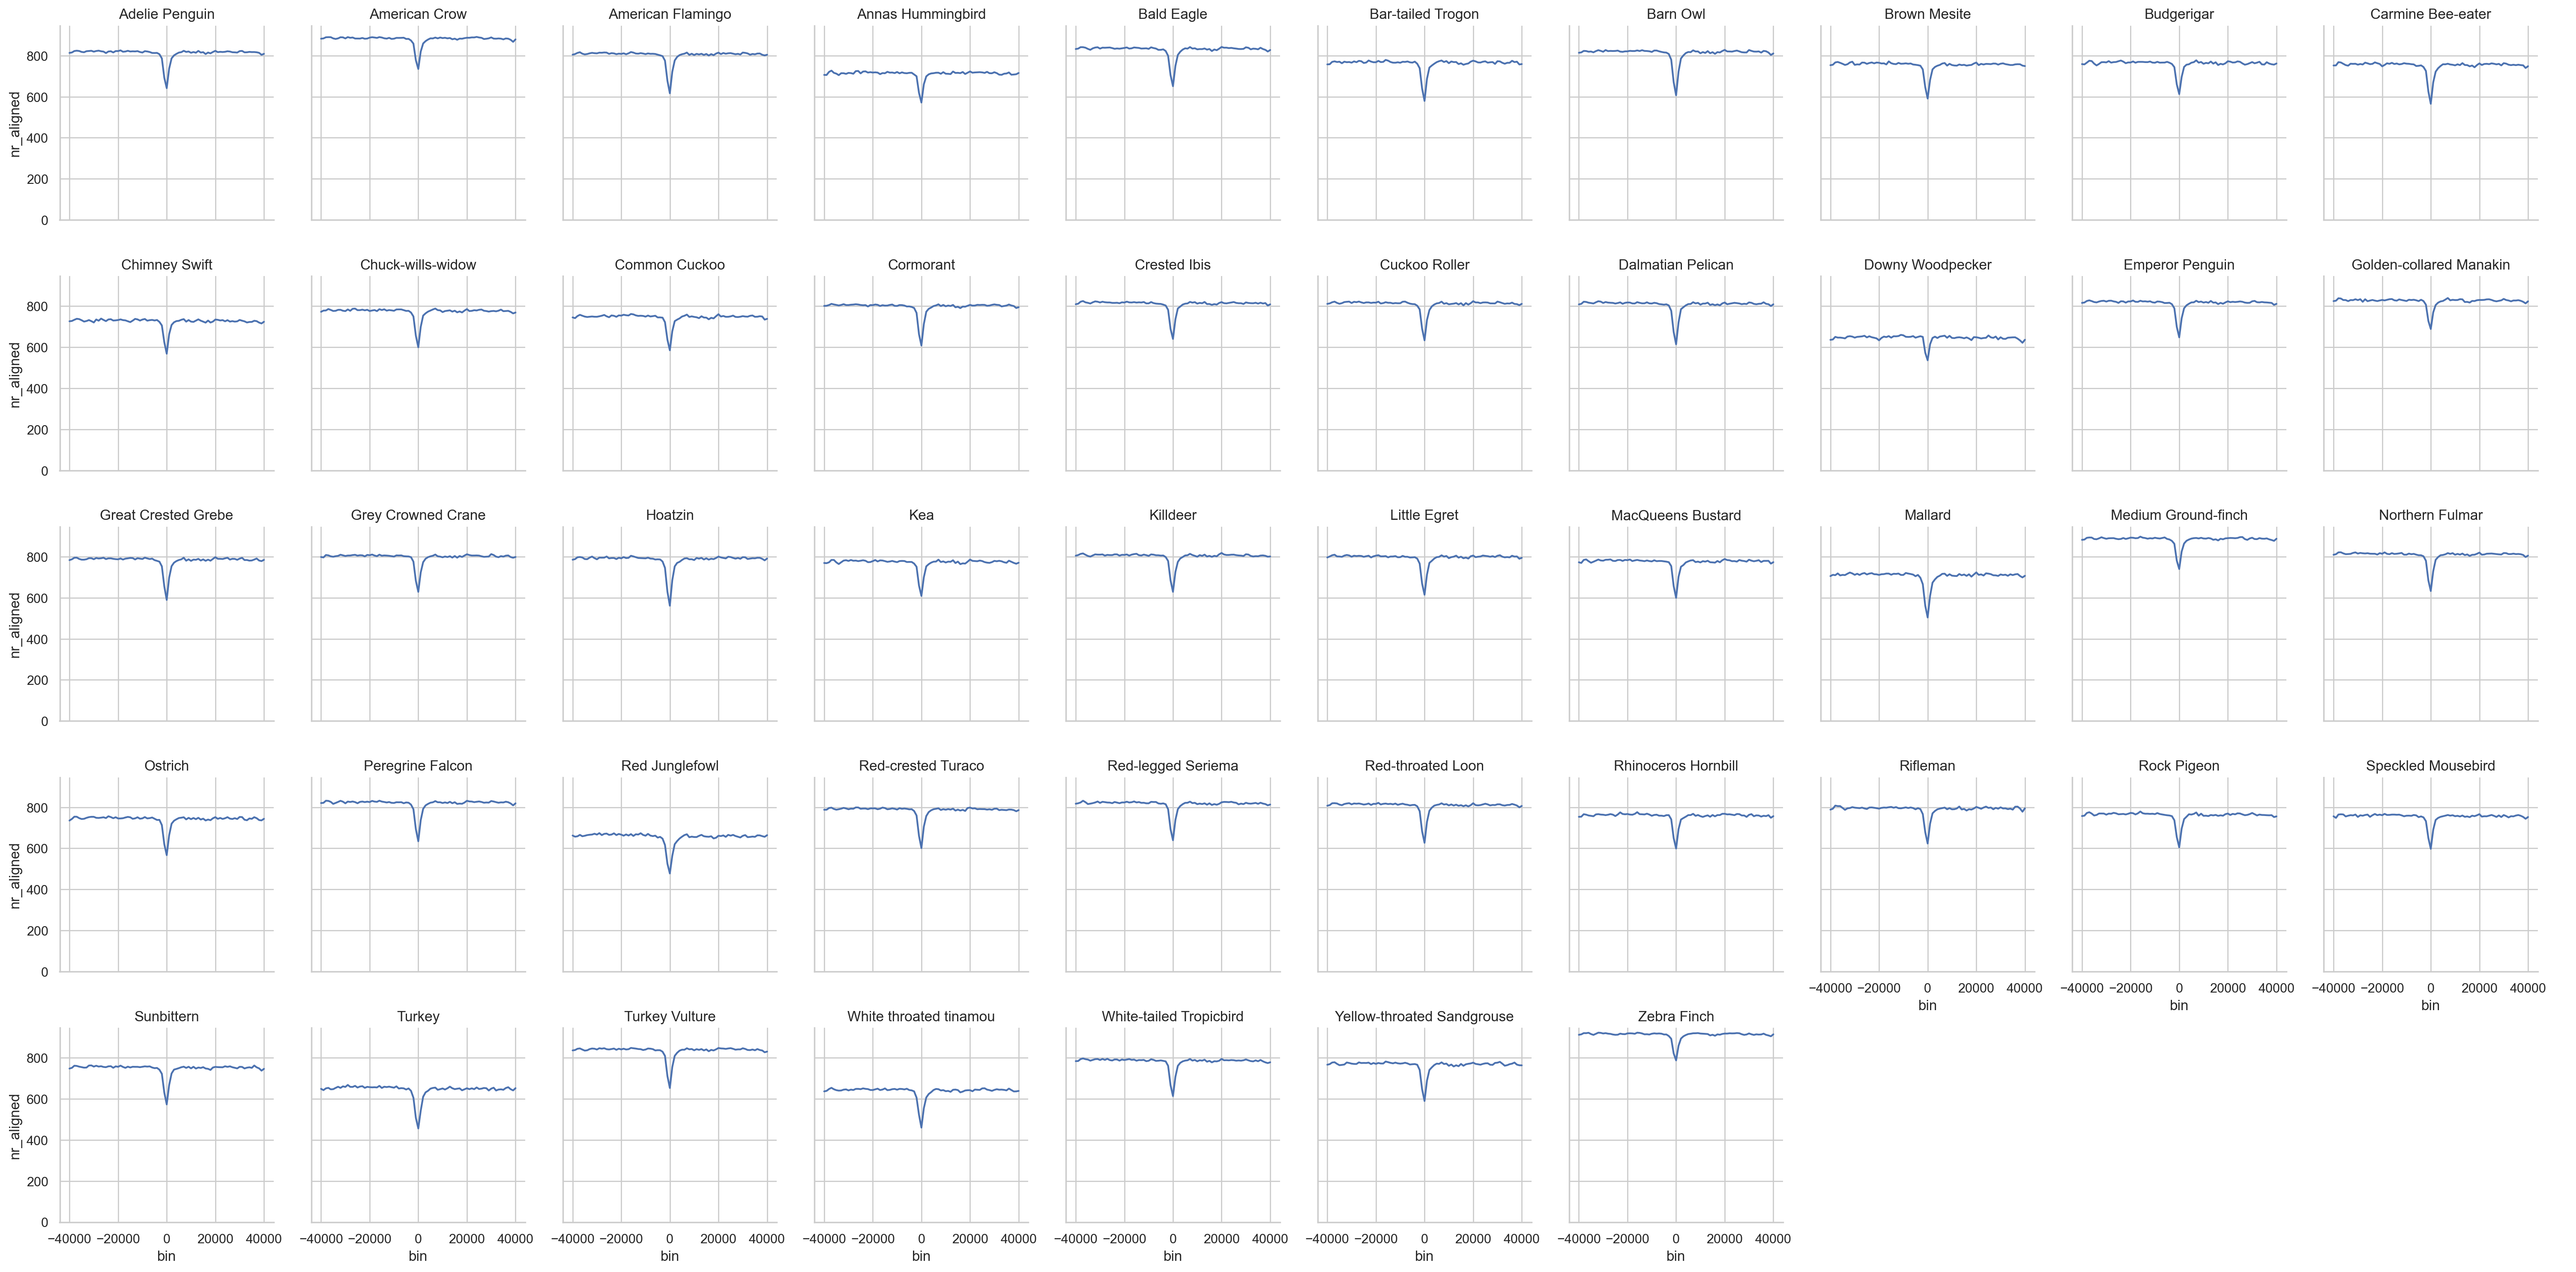

In [42]:
with sns.axes_style('whitegrid'):
    g = sns.FacetGrid(subst_data,
                      col='species', col_wrap=10, sharey=True)
    g.map(sns.lineplot, 'bin', 'nr_aligned', errorbar=None).add_legend()
    g.set_titles(row_template = '{row_name}', col_template = '{col_name}') ;
    [ax.set_ylim(bottom=0) for ax in g.axes.flat]
    plt.savefig(figures_path / 'nr_aligned_base_across_hotspots_indiv_species.pdf')        

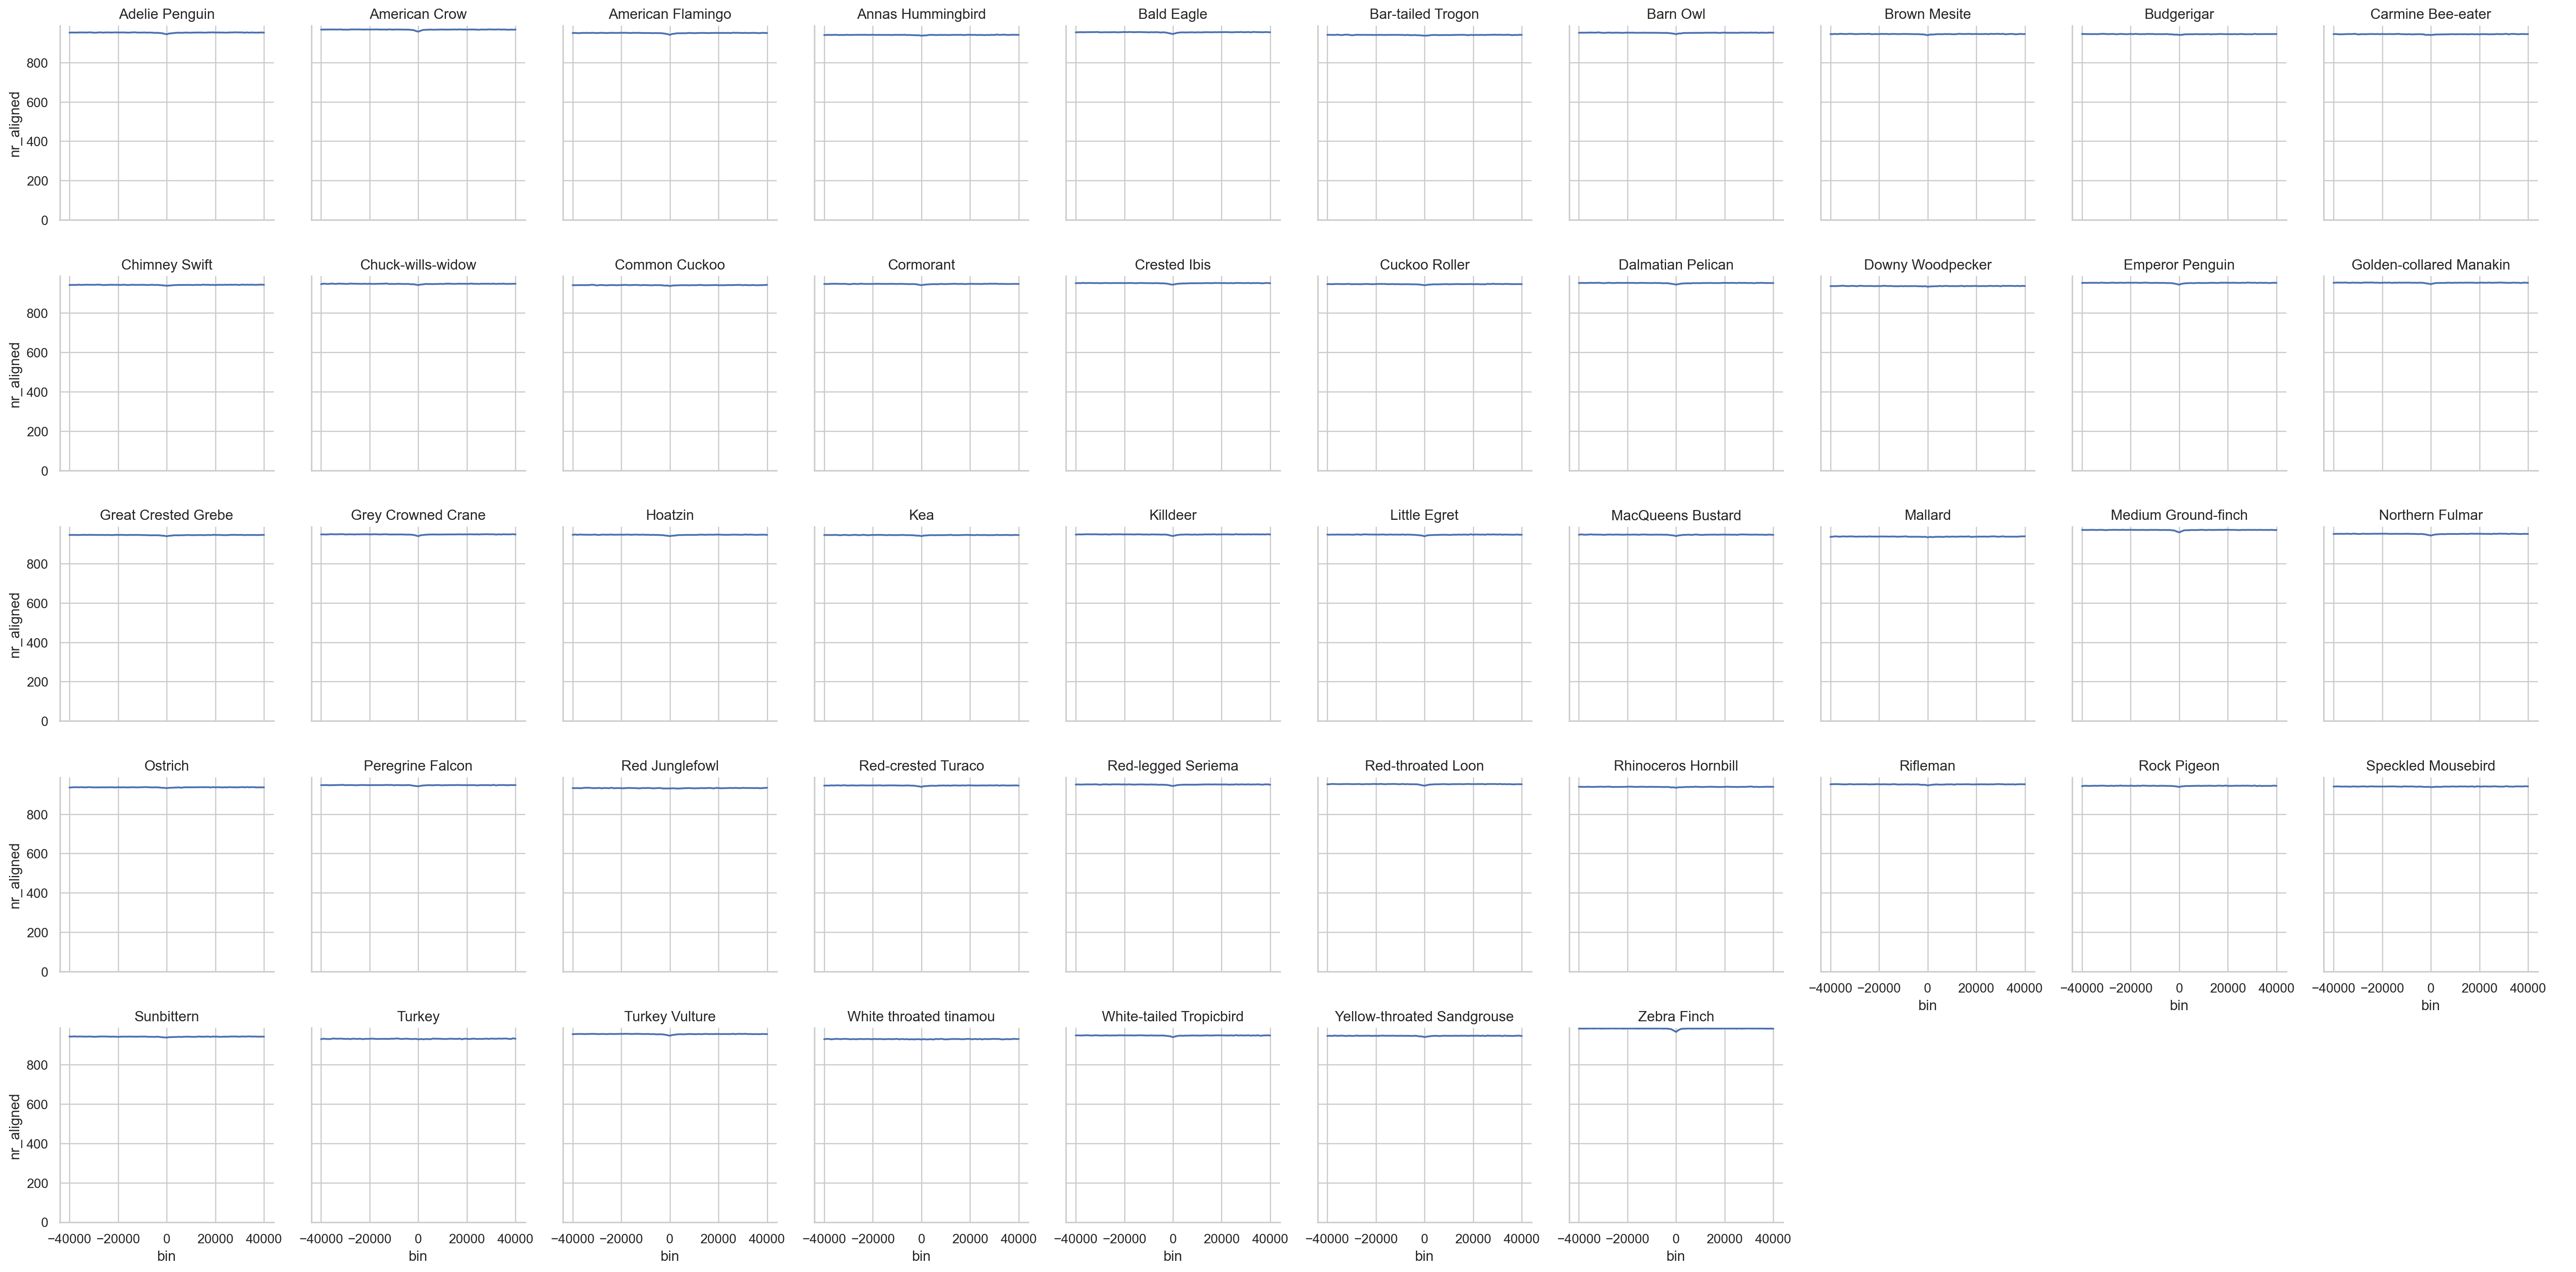

In [43]:
with sns.axes_style('whitegrid'):
    g = sns.FacetGrid(subst_data.loc[subst_data.nr_aligned >= 900],
                      col='species', col_wrap=10, sharey=True)
    g.map(sns.lineplot, 'bin', 'nr_aligned', errorbar=None).add_legend()
    g.set_titles(row_template = '{row_name}', col_template = '{col_name}') ;
    [ax.set_ylim(bottom=0) for ax in g.axes.flat]
    plt.savefig(figures_path / 'nr_aligned_base_across_hotspots_indiv_species_only_min900bases.pdf')            

> It seems there are important differences in the alignemnt quality in the different species. Especially with some of the long branches. 

> We will be asked how much of the differences we find are due to misalignemnts. To that we can say that any misalignment will inflate all substitution rates at hotspots not just a few. As we show further down, the A2T and T2A substitution rates are constant across the hotspots.

We use only windows where with at least 300 aligned bases. (below we also test if this cutoff matters to the patterns observed)

In [44]:
removed_rows = subst_data[subst_data.nr_aligned < 300].index
subst_data.drop(removed_rows, inplace=True)

Normalize each substitution rate with a global mutation rate divided by the external branch length. 

By dividing by branch length we take variation in overall subsititution rate into account. This should make the summed substitituion rates outside hotspots should be the same across species.

In [45]:
#subst_data['rate'] /= subst_data.branch_length

In [46]:
optimize_data_frame(subst_data, inplace=True)
subst_data.head()

,species_code,pattern,flank_rate,species,ancestor,hotspot_center,bin,branch_length,ultra_branch_length,nr_aligned,rate,type
0,CORBR,rA2C,0.005816,American Crow,Anc44,6894116,0.0,0.038474,0.035454,409,3.508902,Transversion
1,CORBR,rA2C,0.005816,American Crow,Anc44,8805005,0.0,0.038474,0.035454,899,0.582834,Transversion
2,CORBR,rA2C,0.005816,American Crow,Anc44,9687030,0.0,0.038474,0.035454,991,1.181692,Transversion
3,CORBR,rA2C,0.005816,American Crow,Anc44,10397061,0.0,0.038474,0.035454,908,1.976278,Transversion
4,CORBR,rA2C,0.005816,American Crow,Anc44,10503751,0.0,0.038474,0.035454,568,0.000000,Transversion


It seems one hotspot appears twice. Remove that one so positions remain unqiue across chromosomesÆ

In [47]:
subst_data = subst_data.loc[subst_data.hotspot_center != 11341000]

In [48]:
sorted(subst_data.species.unique().to_list())

['Adelie Penguin',
 'American Crow',
 'American Flamingo',
 'Annas Hummingbird',
 'Bald Eagle',
 'Bar-tailed Trogon',
 'Barn Owl',
 'Brown Mesite',
 'Budgerigar',
 'Carmine Bee-eater',
 'Chimney Swift',
 'Chuck-wills-widow',
 'Common Cuckoo',
 'Cormorant',
 'Crested Ibis',
 'Cuckoo Roller',
 'Dalmatian Pelican',
 'Downy Woodpecker',
 'Emperor Penguin',
 'Golden-collared Manakin',
 'Great Crested Grebe',
 'Grey Crowned Crane',
 'Hoatzin',
 'Kea',
 'Killdeer',
 'Little Egret',
 'MacQueens Bustard',
 'Mallard',
 'Medium Ground-finch',
 'Northern Fulmar',
 'Ostrich',
 'Peregrine Falcon',
 'Red Junglefowl',
 'Red-crested Turaco',
 'Red-legged Seriema',
 'Red-throated Loon',
 'Rhinoceros Hornbill',
 'Rifleman',
 'Rock Pigeon',
 'Speckled Mousebird',
 'Sunbittern',
 'Turkey',
 'Turkey Vulture',
 'White throated tinamou',
 'White-tailed Tropicbird',
 'Yellow-throated Sandgrouse',
 'Zebra Finch']

In [49]:
subst_data.to_hdf('../results/subst_data.h5', key='df', format='table')

And the same including CpG sites:

In [50]:
hotspot_data_incl_cpg = pd.read_hdf('../results/hotspot_data_incl_cpg.h5')

In [51]:
subst_data_incl_cpg = (hotspot_data_incl_cpg
              .loc[lambda df: df.bin.abs() <= 40000, id_cols + all_substitutions + base_counts]
              .melt(id_vars=id_cols,
                    value_vars=all_substitutions,
                    var_name='pattern', value_name='rate')
             )
subst_data_incl_cpg['pattern'] = pd.Categorical(subst_data_incl_cpg.pattern.values, 
                                       categories=all_substitutions, ordered=True)
subst_data_incl_cpg.loc[subst_data_incl_cpg.pattern.isin(transitions), 'type'] = 'Transition'
subst_data_incl_cpg.loc[~subst_data_incl_cpg.pattern.isin(transitions), 'type'] = 'Transversion'
subst_data_incl_cpg['type'] = pd.Categorical(subst_data_incl_cpg.type.values, categories=['Transition', 'Transversion'], ordered=True)

# scale with flank means
subst_data_incl_cpg = (subst_data_incl_cpg
 .loc[subst_data_incl_cpg.bin.abs() > flank_start]
 .groupby(['species_code', 'pattern'], observed=False)
 .rate
 .mean()
 .reset_index()
 .rename(columns={'rate':'flank_rate'}) 
).merge(subst_data_incl_cpg, on=['species_code', 'pattern'], how='right')
subst_data_incl_cpg['rate'] /= subst_data_incl_cpg['flank_rate']
subst_data_incl_cpg.head()

,species_code,pattern,flank_rate,species,ancestor,hotspot_center,bin,branch_length,ultra_branch_length,nr_aligned,rate,type
0,CORBR,rA2C,0.006709,American Crow,Anc44,6894116,0.0,0.038474,0.035454,409,4.471794,Transversion
1,CORBR,rA2C,0.006709,American Crow,Anc44,8805005,0.0,0.038474,0.035454,899,0.503580,Transversion
2,CORBR,rA2C,0.006709,American Crow,Anc44,9687030,0.0,0.038474,0.035454,991,1.027999,Transversion
3,CORBR,rA2C,0.006709,American Crow,Anc44,10397061,0.0,0.038474,0.035454,908,1.687469,Transversion
4,CORBR,rA2C,0.006709,American Crow,Anc44,10503751,0.0,0.038474,0.035454,568,0.000000,Transversion


We use only windows where with at least 300 aligned bases. (below we also test if this cutoff matters to the patterns observed)

In [52]:
removed_rows = subst_data_incl_cpg[subst_data_incl_cpg.nr_aligned < 300].index
subst_data_incl_cpg.drop(removed_rows, inplace=True)

Normalize each substitution rate with a global mutation rate divided by the external branch length. 

By dividing by branch length we take variation in overall subsititution rate into account. This should make the summed substitituion rates outside hotspots should be the same across species.

In [53]:
#subst_data_incl_cpg['rate'] /= subst_data_incl_cpg.branch_length

In [54]:
optimize_data_frame(subst_data_incl_cpg, inplace=True)
subst_data_incl_cpg.head()

,species_code,pattern,flank_rate,species,ancestor,hotspot_center,bin,branch_length,ultra_branch_length,nr_aligned,rate,type
0,CORBR,rA2C,0.006709,American Crow,Anc44,6894116,0.0,0.038474,0.035454,409,4.471794,Transversion
1,CORBR,rA2C,0.006709,American Crow,Anc44,8805005,0.0,0.038474,0.035454,899,0.503580,Transversion
2,CORBR,rA2C,0.006709,American Crow,Anc44,9687030,0.0,0.038474,0.035454,991,1.027999,Transversion
3,CORBR,rA2C,0.006709,American Crow,Anc44,10397061,0.0,0.038474,0.035454,908,1.687469,Transversion
4,CORBR,rA2C,0.006709,American Crow,Anc44,10503751,0.0,0.038474,0.035454,568,0.000000,Transversion


It seems one hotspot appears twice...

In [55]:
subst_data_incl_cpg = subst_data_incl_cpg.loc[subst_data_incl_cpg.hotspot_center != 11341000]

In [56]:
subst_data_incl_cpg.to_hdf('../results/subst_data_incl_cpg.h5', key='df', format='table')

In [57]:
del hotspot_data
del hotspot_data_incl_cpg
gc.collect()

137290

See if the summed substitituion rates outside hotspots are the same across species:

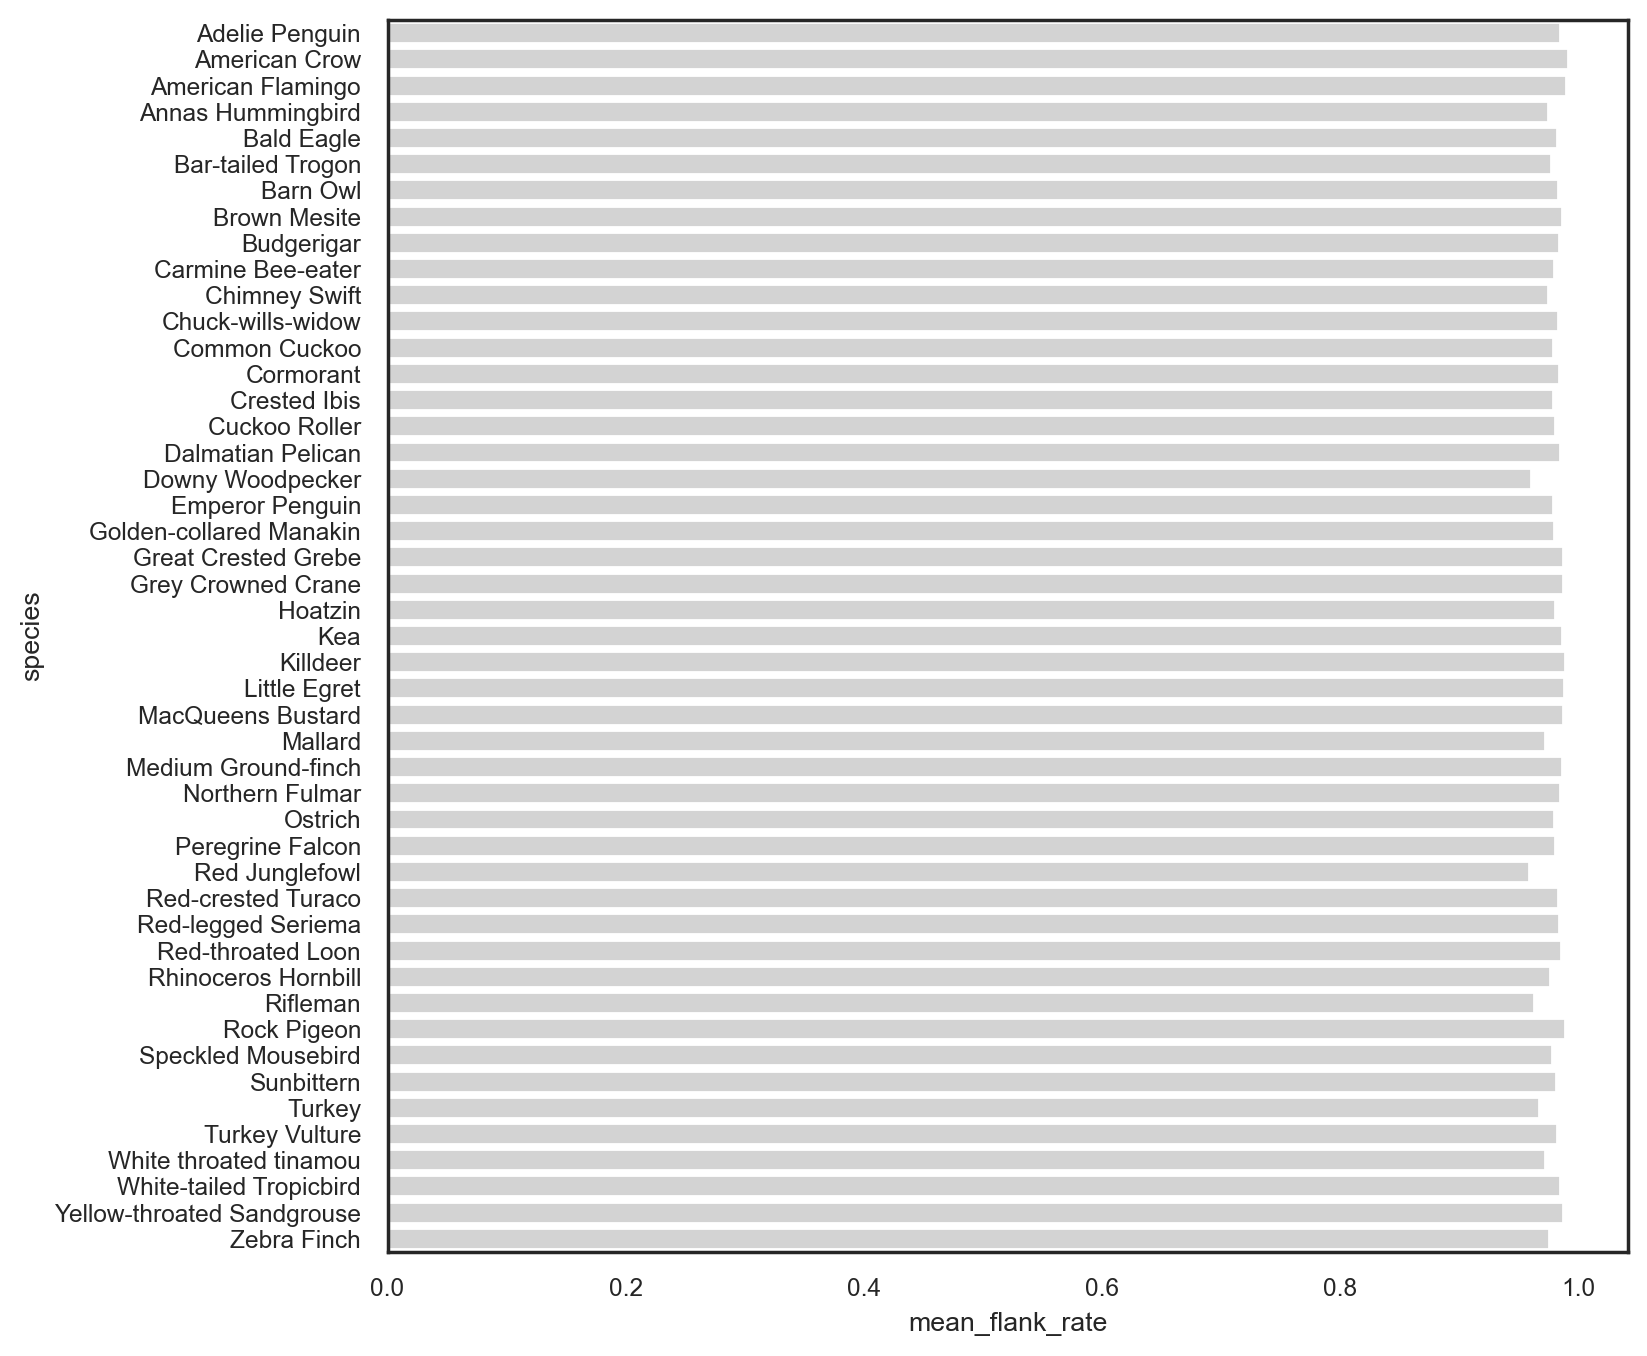

In [58]:
mean_flank_rates = (subst_data
                    .loc[subst_data.bin.abs() > flank_start]
                    .groupby('species', observed=False)
                    .rate
                    .mean()
                    .reset_index()
                    .rename(columns={'rate': 'mean_flank_rate'})
                    )
with sns.plotting_context('notebook', font_scale=0.8):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax = sns.barplot(y="species", x="mean_flank_rate", data=mean_flank_rates, color='lightgrey')
    plt.savefig(figures_path / 'mean_norm_flank_subst_rates.pdf')                

# Pivot table with column for each pattern (rate_table)

Rates are means across windows in the same position across hotspots.

In [59]:
subst_data.species.cat.categories

Index(['Adelie Penguin', 'American Crow', 'American Flamingo',
       'Annas Hummingbird', 'Bald Eagle', 'Bar-tailed Trogon', 'Barn Owl',
       'Brown Mesite', 'Budgerigar', 'Carmine Bee-eater', 'Chimney Swift',
       'Chuck-wills-widow', 'Common Cuckoo', 'Cormorant', 'Crested Ibis',
       'Cuckoo Roller', 'Dalmatian Pelican', 'Downy Woodpecker',
       'Emperor Penguin', 'Golden-collared Manakin', 'Great Crested Grebe',
       'Grey Crowned Crane', 'Hoatzin', 'Kea', 'Killdeer', 'Little Egret',
       'MacQueens Bustard', 'Mallard', 'Medium Ground-finch',
       'Northern Fulmar', 'Ostrich', 'Peregrine Falcon', 'Red Junglefowl',
       'Red-crested Turaco', 'Red-legged Seriema', 'Red-throated Loon',
       'Rhinoceros Hornbill', 'Rifleman', 'Rock Pigeon', 'Speckled Mousebird',
       'Sunbittern', 'Turkey', 'Turkey Vulture', 'White throated tinamou',
       'White-tailed Tropicbird', 'Yellow-throated Sandgrouse', 'Zebra Finch'],
      dtype='object')

In [60]:
rate_table = pd.pivot_table(subst_data, observed=False,
                            index=['species', 'species_code', 'bin'], columns='pattern', values='rate')

rate_table.columns = rate_table.columns.astype('str')
for a, b in paired_patterns:
    rate_table[f'{a}-{b}'] = rate_table[a] - rate_table[b]
rate_table.head()

pattern                                   rA2C      rT2G      rC2T      rG2A  \
species        species_code bin                                                
Adelie Penguin PYGAD        -40000.0  0.927578  0.926622  1.001832  0.974554   
                            -39000.0  0.961294  0.922865  0.992271  1.022938   
                            -38000.0  0.935713  0.900372  0.944196  0.979256   
                            -37000.0  0.946277  0.955108  1.014483  0.989802   
                            -36000.0  0.968638  0.920229  0.992303  1.042423   

pattern                                   rA2G      rT2C      rA2T      rT2A  \
species        species_code bin                                                
Adelie Penguin PYGAD        -40000.0  0.990505  0.965529  0.993105  1.023280   
                            -39000.0  0.954932  0.978933  1.006672  1.000758   
                            -38000.0  0.947075  0.994227  0.969853  1.006931   
                            -37000.0  0.977447  1.018131  1.060473  1.069875   
                            -36000.0  0.991555  0.998956  0.992564  0.951536   

pattern                                   rC2A      rG2T  ...      rA2g  \
species        species_code bin                           ...             
Adelie Penguin PYGAD        -40000.0  1.024986  1.082883  ...  1.012458   
                            -39000.0  0.985127  0.987615  ...  0.999270   
                            -38000.0  0.975919  0.989658  ...  0.965188   
                            -37000.0  0.915125  1.014733  ...  0.989556   
                            -36000.0  1.000565  1.008551  ...  1.001119   

pattern                                   rT2c      rc2g      rg2c  rT2G-rA2C  \
species        species_code bin                                                 
Adelie Penguin PYGAD        -40000.0  0.993055  0.564724  0.249302  -0.000955   
                            -39000.0  0.954479  0.667724  0.948971  -0.038429   
                            -38000.0  1.054523  0.880312  0.707583  -0.035342   
                            -37000.0  0.994172  0.419302  1.113465   0.008831   
                            -36000.0  1.005124  0.962499  1.166514  -0.048409   

pattern                               rA2G-rT2C  rA2T-rT2A  rG2T-rC2A  \
species        species_code bin                                         
Adelie Penguin PYGAD        -40000.0   0.024976  -0.030175   0.057897   
                            -39000.0  -0.024001   0.005914   0.002488   
                            -38000.0  -0.047152  -0.037077   0.013739   
                            -37000.0  -0.040683  -0.009402   0.099608   
                            -36000.0  -0.007401   0.041028   0.007985   

pattern                               rC2G-rG2C  rC2T-rG2A  
species        species_code bin                             
Adelie Penguin PYGAD        -40000.0  -0.018405   0.027278  
                            -39000.0  -0.033624  -0.030667  
                            -38000.0  -0.034808  -0.035061  
                            -37000.0   0.019050   0.024682  
                            -36000.0  -0.008371  -0.050120  

[5 rows x 24 columns]

In [61]:
rate_table.reset_index().species.cat.categories

Index(['Adelie Penguin', 'American Crow', 'American Flamingo',
       'Annas Hummingbird', 'Bald Eagle', 'Bar-tailed Trogon', 'Barn Owl',
       'Brown Mesite', 'Budgerigar', 'Carmine Bee-eater', 'Chimney Swift',
       'Chuck-wills-widow', 'Common Cuckoo', 'Cormorant', 'Crested Ibis',
       'Cuckoo Roller', 'Dalmatian Pelican', 'Downy Woodpecker',
       'Emperor Penguin', 'Golden-collared Manakin', 'Great Crested Grebe',
       'Grey Crowned Crane', 'Hoatzin', 'Kea', 'Killdeer', 'Little Egret',
       'MacQueens Bustard', 'Mallard', 'Medium Ground-finch',
       'Northern Fulmar', 'Ostrich', 'Peregrine Falcon', 'Red Junglefowl',
       'Red-crested Turaco', 'Red-legged Seriema', 'Red-throated Loon',
       'Rhinoceros Hornbill', 'Rifleman', 'Rock Pigeon', 'Speckled Mousebird',
       'Sunbittern', 'Turkey', 'Turkey Vulture', 'White throated tinamou',
       'White-tailed Tropicbird', 'Yellow-throated Sandgrouse', 'Zebra Finch'],
      dtype='object')

In [62]:
rate_table.to_hdf('../results/rate_table.h5', key='df', format='table')

In [63]:
rate_table_incl_cpg = pd.pivot_table(subst_data_incl_cpg, observed=False,
                            index=['species', 'species_code', 'bin'], columns='pattern', values='rate')
rate_table_incl_cpg.columns = rate_table_incl_cpg.columns.astype('str')
for a, b in paired_patterns:
    rate_table_incl_cpg[f'{a}-{b}'] = rate_table_incl_cpg[a] - rate_table_incl_cpg[b]
rate_table_incl_cpg.head()

pattern                                   rA2C      rT2G      rC2T      rG2A  \
species        species_code bin                                                
Adelie Penguin PYGAD        -40000.0  0.926982  0.948231  1.007925  0.988771   
                            -39000.0  0.993481  0.938154  0.983537  1.023180   
                            -38000.0  0.954980  0.918715  0.952623  1.000090   
                            -37000.0  0.946085  0.972950  1.026525  0.987673   
                            -36000.0  0.979226  0.946731  0.991745  1.027370   

pattern                                   rA2G      rT2C      rA2T      rT2A  \
species        species_code bin                                                
Adelie Penguin PYGAD        -40000.0  0.999237  0.976058  0.992943  1.023043   
                            -39000.0  0.971101  0.971965  1.006620  1.000614   
                            -38000.0  0.954451  1.015763  0.970148  1.006581   
                            -37000.0  0.982769  1.011195  1.060489  1.070141   
                            -36000.0  0.995825  1.002129  0.992188  0.951461   

pattern                                   rC2A      rG2T  ...      rA2g  \
species        species_code bin                           ...             
Adelie Penguin PYGAD        -40000.0  1.015140  1.079797  ...  1.012458   
                            -39000.0  0.980063  1.003583  ...  0.999270   
                            -38000.0  0.966796  0.974752  ...  0.965188   
                            -37000.0  0.910210  1.020666  ...  0.989556   
                            -36000.0  1.004690  1.018201  ...  1.001119   

pattern                                   rT2c      rc2g      rg2c  rT2G-rA2C  \
species        species_code bin                                                 
Adelie Penguin PYGAD        -40000.0  0.993055  0.564724  0.249302   0.021249   
                            -39000.0  0.954479  0.667724  0.948971  -0.055327   
                            -38000.0  1.054523  0.880312  0.707583  -0.036265   
                            -37000.0  0.994172  0.419302  1.113465   0.026865   
                            -36000.0  1.005124  0.962499  1.166514  -0.032496   

pattern                               rA2G-rT2C  rA2T-rT2A  rG2T-rC2A  \
species        species_code bin                                         
Adelie Penguin PYGAD        -40000.0   0.023179  -0.030100   0.064657   
                            -39000.0  -0.000863   0.006006   0.023521   
                            -38000.0  -0.061312  -0.036433   0.007956   
                            -37000.0  -0.028426  -0.009651   0.110455   
                            -36000.0  -0.006304   0.040727   0.013512   

pattern                               rC2G-rG2C  rC2T-rG2A  
species        species_code bin                             
Adelie Penguin PYGAD        -40000.0  -0.009878   0.019154  
                            -39000.0  -0.039479  -0.039643  
                            -38000.0  -0.034642  -0.047467  
                            -37000.0   0.017916   0.038852  
                            -36000.0  -0.008687  -0.035625  

[5 rows x 24 columns]

In [64]:
rate_table_incl_cpg.to_hdf('../results/rate_table_incl_cpg.h5', key='df', format='table')

In [65]:
del rate_table
del rate_table_incl_cpg
gc.collect()

115

# Mean GC* for each chromosome of each species

In [66]:
records = []
for species in species_details.species:
    if species in ['HALAL']:
        continue
    for chrom in chromosomes:
        f_name = f'/home/kmt/Birds/faststorage/data/composition/{species}/chr{chrom}.ancestor.composition.1000.txt'
        try:
            df = pd.read_csv(f_name, sep='\t')
            nA, nT, nG, nC = df.nA_tot.sum(), df.nT_tot.sum(), df.nG_tot.sum(), df.nC_tot.sum()
            GCcontent = (nG + nC) / (nA + nT + nG + nC)
            GCflux = (df.nA2G.sum()/nA + df.nA2C.sum()/nA + df.nT2G.sum()/nT + df.nT2C.sum()/nT) / \
                     (df.nC2A.sum()/nC + df.nC2T.sum()/nC + df.nG2A.sum()/nG + df.nG2T.sum()/nG)
            GCstar = GCflux/(1 + GCflux)
            records.append([species, chrom, GCstar, GCflux, GCcontent])
        except:
            pass
            #print('missing:', f_name)

In [67]:
chromosome_GCstar = pd.DataFrame.from_records(records, columns=['species_code', 'chrom', 'GCstar', 'GCflux', 'GCcontent'])

chromosome_GCstar = (chromosome_GCstar
                     .merge(species_details.rename(columns={'species': 'species_code'})[['species_code', 'english']], 
                            on='species_code', how='left')
                     .rename(columns={'english': 'species'})
                    )

chromosome_GCstar.head()

,species_code,chrom,GCstar,GCflux,GCcontent,species
0,PICPU,1,0.416573,0.714010,0.395756,Downy Woodpecker
1,PICPU,1A,0.459046,0.848588,0.407914,Downy Woodpecker
2,PICPU,2,0.506001,1.024294,0.412536,Downy Woodpecker
3,PICPU,3,0.463857,0.865173,0.406441,Downy Woodpecker
4,PICPU,4,0.531253,1.133349,0.411582,Downy Woodpecker


In [68]:
chromosome_GCstar.to_hdf('../results/chromosome_GCstar.h5', key='df')

In [69]:
del chromosome_GCstar
gc.collect()

75

# Read hotspot distances relative to CGI, TSS and TES

## CGI relative data

In [70]:
df_list = list()
for path in remapped_data_path.iterdir():
    if path.name.endswith('.cgi_relative.txt'):
        df = pd.read_csv(str(path), sep='\t', low_memory=False)
        df_list.append(df)
cgi_table = pd.concat(df_list, sort=True).merge(branch_lengths, on=['species', 'ancestor'], how='left')

optimize_data_frame(cgi_table).to_hdf(results_path / 'cgi_data.h5', key='df', mode='w', format='table')

In [71]:
del cgi_table
gc.collect()

278

## Promoter relative data

In [72]:
df_list = list()
for path in remapped_data_path.iterdir():
    if path.name.endswith('.promoter_relative.txt'):
        df = pd.read_csv(str(path), sep='\t', low_memory=False)
        df_list.append(df)
promoter_table = pd.concat(df_list, sort=True).merge(branch_lengths, on=['species', 'ancestor'], how='left')

optimize_data_frame(promoter_table).to_hdf(results_path / 'promoter_data.h5', key='df', mode='w', format='table')

In [73]:
del promoter_table
gc.collect()

278

## TSS relative data

In [74]:
df_list = list()
for path in remapped_data_path.iterdir():
    if path.name.endswith('.tss_relative.txt'):
        df = pd.read_csv(str(path), sep='\t', low_memory=False)
        df_list.append(df)
tss_table = pd.concat(df_list, sort=True).merge(branch_lengths, on=['species', 'ancestor'], how='left')

optimize_data_frame(tss_table).to_hdf(results_path / 'tss_data.h5', key='df', mode='w', format='table')

In [75]:
del tss_table
gc.collect()

278

## TES relative data

In [76]:
df_list = list()
for path in remapped_data_path.iterdir():
    if path.name.endswith('.tes_relative.txt'):
        df = pd.read_csv(str(path), sep='\t', low_memory=False)
        df_list.append(df)
tes_table = pd.concat(df_list, sort=True).merge(branch_lengths, on=['species', 'ancestor'], how='left')

optimize_data_frame(tes_table).to_hdf(results_path / 'tes_data.h5', key='df', mode='w', format='table')

In [77]:
del tes_table
gc.collect()

278

# Distance to CGI, TSS, TES, and promoter (hotspot_anno_dist)

Hotspot distance to center of closest CGI, TSS, TES, and promoter:

In [78]:
def read_dist_data(file_name):
    del_cols = ['pos', 'start', 'end', 'start_prox', 'end_prox', 'start_orig', 'end_orig']
    return (pd.read_csv(file_name, sep='\t')
            .assign(
                    hotspot_center=lambda df: (df.start_orig + (df.end_orig - df.start_orig) / 2).astype('int32'),
                    dist=lambda df: (df.start.abs()+(df.end.abs()-df.start.abs())/2).astype('int32'),
                   )
            .drop(del_cols, axis=1)
           )

remapped_data_path = data_path / 'composition_cpg_remapped'

def remove_duplicates(df):
    return df.sample(frac=1).reset_index(drop=True).drop_duplicates(subset=['chrom', 'hotspot_center'])

hotspot_rel_cgi_data = read_dist_data(remapped_data_path / 'hotspot_rel_cgi.txt')
hotspot_rel_promoter_data = read_dist_data(remapped_data_path / 'hotspot_rel_promoter.txt')
hotspot_rel_tss_data = read_dist_data(remapped_data_path / 'hotspot_rel_tss.txt')
hotspot_rel_tes_data = read_dist_data(remapped_data_path / 'hotspot_rel_tes.txt')

# There are duplicate rows for two reasons: 
# 1. a lot of hotspots overlap more than one cgi. 
# 2. a few hotspots ~50 are split because they overlap the midpoint between
# So in case of duplicates we keep only one at random.

hotspot_rel_cgi_data = remove_duplicates(hotspot_rel_cgi_data)
hotspot_rel_promoter_data = remove_duplicates(hotspot_rel_promoter_data)
hotspot_rel_tss_data = remove_duplicates(hotspot_rel_tss_data)
hotspot_rel_tes_data = remove_duplicates(hotspot_rel_tes_data)

hotspot_rel_cgi_data.rename(columns={'bin': 'bin_cgi', 'dist': 'dist_cgi'}, inplace=True)
hotspot_rel_promoter_data.rename(columns={'bin': 'bin_promoter', 'dist': 'dist_promoter'}, inplace=True)
hotspot_rel_tss_data.rename(columns={'bin': 'bin_tss', 'dist': 'dist_tss'}, inplace=True)
hotspot_rel_tes_data.rename(columns={'bin': 'bin_tes', 'dist': 'dist_tes'}, inplace=True)

In [79]:
merge_cols = ['chrom', 'hotspot_center']
hotspot_anno_dist = (hotspot_rel_cgi_data
                     .merge(hotspot_rel_tss_data)
                     .merge(hotspot_rel_tes_data)
                     .merge(hotspot_rel_promoter_data)
                     .sort_values(['chrom', 'hotspot_center'])
                    )
hotspot_anno_dist.head()

,chrom,bin_cgi,hotspot_center,dist_cgi,bin_tss,dist_tss,bin_tes,dist_tes,bin_promoter,dist_promoter
1085,1,0.0,6894116,0,56000.0,55690,31000.0,31212,56000.0,56190
147,1,0.0,8805005,0,-459000.0,458971,430000.0,429995,-459000.0,458721
2331,1,14000.0,9687030,14220,423000.0,422594,-496000.0,495556,423000.0,423094
748,1,2000.0,10397061,2419,3000.0,2935,2000.0,2063,3000.0,3435
1650,1,0.0,10503751,0,0.0,0,0.0,0,0.0,0


In [80]:
hotspot_anno_dist.to_hdf('../results/hotspot_anno_dist.h5', key='df', format='table')

In [81]:
del hotspot_rel_cgi_data
del hotspot_rel_promoter_data
del hotspot_rel_tss_data
del hotspot_rel_tes_data
del hotspot_anno_dist
gc.collect()

64

# GC*

## GC* of new mutations

Aggregate 1kb GC* in 200kb windows and record the 1 percentile GC* for each species:

In [82]:
from chromwindow import window

@window(size=200000)
def window_gcstar(df):
    nA, nT, nG, nC = df.nA_tot.sum(), df.nT_tot.sum(), df.nG_tot.sum(), df.nC_tot.sum()
    if nA + nT + nG + nC < 100000:
        return np.nan
    toGC = df.nA2G.sum()/nA + df.nA2C.sum()/nA + df.nT2G.sum()/nT + df.nT2C.sum()/nT
    toAT = df.nC2A.sum()/nC + df.nC2T.sum()/nC + df.nG2A.sum()/nG + df.nG2T.sum()/nG
    if not toAT:
        return np.nan
    GCflux = toGC / toAT
    GCstar = GCflux/(1 + GCflux)
    return GCstar

records = []
big_df_list = []
for species, species_code in list(zip(species_details.english, species_details.species2014)):
    if species_code in ['HALAL']:
        continue
    df_list = []
    for chrom in chromosomes:
        f_name = f'/home/kmt/Birds/faststorage/data/composition/{species_code}/chr{chrom}.ancestor.composition.1000.txt'
        if not os.path.exists(f_name):
            print('Missing:', species_code, chrom)
            continue
        df = pd.read_csv(f_name, sep='\t')
        df['end'] = df.start + 1000
        df['chrom'] = chrom
        df['species'] = species
        df['species_code'] = species_code 
        df_list.append(df)
    if df_list:
        df = pd.concat(df_list).groupby(['chrom', 'species', 'species_code']).apply(window_gcstar).reset_index()
        records.append((species, species_code, df.window_gcstar.quantile(0.01)))
        big_df_list.append(df)
        
gcstar_200kb_windows = pd.concat(big_df_list)
gcstar_200kb_windows.head()

,chrom,species,species_code,level_3,start,end,window_gcstar
0,1,Downy Woodpecker,PICPU,0,0,200000,NaN
1,1,Downy Woodpecker,PICPU,1,200000,400000,NaN
2,1,Downy Woodpecker,PICPU,2,400000,600000,0.377815
3,1,Downy Woodpecker,PICPU,3,600000,800000,NaN
4,1,Downy Woodpecker,PICPU,4,800000,1000000,0.399671


In [83]:
gcstar_200kb_windows.to_hdf('../results/gcstar_200kb_windows.h5', 'df')

In [84]:
one_percent_gcstar_quantiles = pd.DataFrame().from_records(records, columns=['species', 'species_code', 'GCstar_mut'])
one_percent_gcstar_quantiles.head()

,species,species_code,GCstar_mut
0,Downy Woodpecker,PICPU,0.303483
1,Carmine Bee-eater,MERNU,0.295427
2,Rhinoceros Hornbill,BUCRH,0.338145
3,Bar-tailed Trogon,APAVI,0.290873
4,Cuckoo Roller,LEPDI,0.316841


In [85]:
one_percent_gcstar_quantiles.to_hdf('../results/one_percent_gcstar_quantiles.h5', 'df')

In [86]:
del gcstar_200kb_windows
del one_percent_gcstar_quantiles
gc.collect()

2410

## GC* (gc_star_table)

GCflux, is calculated as the AT to GC over GC to AT substitution rate. The equilibrium GC content resulting from this bias, GC*, is calculated as GCflux/(1 + GCflux).


In [87]:
def subst_gc_star(df):
    
    GCflux = (df.rA2G + df.rA2C + df.rT2G + df.rT2C) / \
             (df.rC2A + df.rC2T + df.rG2A + df.rG2T)
    GCstar = GCflux/(1 + GCflux)
    
    GCstar_TV = (df.rA2C + df.rT2G) / (df.rC2A + df.rG2T)
    GCstar_TV = GCstar_TV / (1 + GCstar_TV)

    GCstar_TS = (df.rA2G + df.rT2C) / \
                (df.rC2T + df.rG2A)
    GCstar_TS = GCstar_TS / (1 + GCstar_TS)
    
    return pd.DataFrame(dict(GCstar=GCstar, GCstar_TV=GCstar_TV, GCstar_TS=GCstar_TS))

In [88]:
rate_table = pd.read_hdf('../results/rate_table.h5')

In [89]:
gc_star_table = rate_table.groupby(['species', 'species_code', 'bin'], group_keys=False).apply(subst_gc_star).reset_index()
gc_star_table.head()

,species,species_code,bin,GCstar,GCstar_TV,GCstar_TS
0,Adelie Penguin,PYGAD,-40000.0,0.482645,0.467988,0.497412
1,Adelie Penguin,PYGAD,-39000.0,0.489116,0.488516,0.489701
2,Adelie Penguin,PYGAD,-38000.0,0.492719,0.482969,0.502309
3,Adelie Penguin,PYGAD,-37000.0,0.497626,0.496284,0.498912
4,Adelie Penguin,PYGAD,-36000.0,0.489621,0.484575,0.494508


In [90]:
gc_star_table.to_hdf('../results/gc_star_table.h5', key='df', format='table')

In [91]:
del rate_table
gc.collect()

180

In [92]:
rate_table_incl_cpg = pd.read_hdf('../results/rate_table_incl_cpg.h5')

In [93]:
gc_star_table_incl_cpg = rate_table_incl_cpg.groupby(['species', 'species_code', 'bin'], group_keys=False).apply(subst_gc_star).reset_index()
gc_star_table_incl_cpg.head()

,species,species_code,bin,GCstar,GCstar_TV,GCstar_TS
0,Adelie Penguin,PYGAD,-40000.0,0.484820,0.472328,0.497306
1,Adelie Penguin,PYGAD,-39000.0,0.492647,0.493358,0.491942
2,Adelie Penguin,PYGAD,-38000.0,0.496747,0.491108,0.502231
3,Adelie Penguin,PYGAD,-37000.0,0.497959,0.498462,0.497476
4,Adelie Penguin,PYGAD,-36000.0,0.492588,0.487726,0.497366


In [94]:
gc_star_table_incl_cpg.to_hdf('../results/gc_star_table_incl_cpg.h5', key='df', format='table')

In [95]:
del rate_table_incl_cpg
gc.collect()

180

## GC* long format (gc_star)

In [96]:
gc_star = gc_star_table.melt(id_vars=['species', 'species_code', 'bin'], var_name='variable', value_name='frequency')
gc_star.to_hdf('../results/gc_star.h5', key='df', format='table')

In [97]:
del gc_star
del gc_star_table
gc.collect()

83

In [98]:
gc_star_incl_cpg = gc_star_table_incl_cpg.melt(id_vars=['species', 'species_code', 'bin'], var_name='variable', value_name='frequency')
gc_star_incl_cpg.to_hdf('../results/gc_star_incl_cpg.h5', key='df', format='table')

In [99]:
del gc_star_incl_cpg
del gc_star_table_incl_cpg
gc.collect()

83

# Center vs flanks

## Mean species hotspot strength (hotspot_strengths)

In [100]:
gc_star_table = pd.read_hdf('../results/gc_star_table.h5')
one_percent_gcstar_quantiles = pd.read_hdf('../results/one_percent_gcstar_quantiles.h5')

In [101]:
hotspot_strengths = (pd.merge((gc_star_table.loc[gc_star_table.bin == 0]
                               .groupby(['species', 'species_code'], observed=True)
                               .GCstar.mean()
                               .to_frame('GCstar_hot')
                               .reset_index()
                              ),
                              (gc_star_table.loc[gc_star_table.bin.abs() >= flank_start]
                               .groupby(['species', 'species_code'], observed=True)
                               .GCstar.mean()
                               .to_frame('GCstar_flank')
                               .reset_index()
                              ),
                              on=['species', 'species_code']
                            )
                    .merge(one_percent_gcstar_quantiles, on=['species', 'species_code'], how='left')
                    )

from scipy.special import logit
hotspot_strengths['hotspot_strength'] = \
    (logit(hotspot_strengths.GCstar_hot) - logit(hotspot_strengths.GCstar_mut)) / \
    (logit(hotspot_strengths.GCstar_flank) - logit(hotspot_strengths.GCstar_mut))

hotspot_strengths['log_hotspot_strength'] = np.log2(hotspot_strengths['hotspot_strength'])

In [102]:
hotspot_strengths.to_hdf('../results/hotspot_strengths.h5', key='df', format='table')

In [103]:
del gc_star_table
del one_percent_gcstar_quantiles
del hotspot_strengths
gc.collect()

96

# THIS IS WHAT I WRONG I THINK: HOTSPOTS_RATE_TABLE IS MADE FROM SUBS_DATA, WHICH IS NOT SCALED WITH FLANK. IT SHOULD BE MADE FROM RATE_TABLE SOMEHOW or we could just normalize subst_data instead

## Strength of each hotspot (hotspots_rate_table)

In [104]:
subst_data = pd.read_hdf('../results/subst_data.h5')

In [105]:
df = (subst_data
 .loc[(subst_data.bin == 0) | (subst_data.bin.abs() >= flank_start)]
 .assign(is_center=lambda df: df.bin == 0)
 .groupby(['species', 'species_code', 'hotspot_center', 'pattern', 'is_center'])
 .rate.mean()
 .reset_index()
)

hotspots_rate_table = pd.pivot_table(df,
                            index=['species', 'species_code', 'hotspot_center', 'is_center'], columns='pattern', values='rate')
hotspots_rate_table.columns = hotspots_rate_table.columns.astype('str')
for a, b in paired_patterns:
    hotspots_rate_table[f'{a}-{b}'] = hotspots_rate_table[a] - hotspots_rate_table[b]
hotspots_rate_table.head()

pattern                                                   rA2C      rT2G  \
species        species_code hotspot_center is_center                       
Adelie Penguin PYGAD        86463          False      0.520965  0.583932   
                                           True       0.000000  0.000000   
                            121019         False      0.889028  1.118020   
                                           True       0.000000  0.000000   
                            147199         True       1.662473  0.000000   

pattern                                                   rC2T      rG2A  \
species        species_code hotspot_center is_center                       
Adelie Penguin PYGAD        86463          False      1.164000  0.279279   
                                           True       0.684551  0.000000   
                            121019         False      0.626736  1.073550   
                                           True       1.292186  1.285994   
                            147199         True       1.216980  0.000000   

pattern                                                   rA2G      rT2C  \
species        species_code hotspot_center is_center                       
Adelie Penguin PYGAD        86463          False      1.052336  0.817429   
                                           True       0.000000  0.456568   
                            121019         False      1.273222  0.799523   
                                           True       0.000000  0.589734   
                            147199         True       2.875998  0.668196   

pattern                                                   rA2T      rT2A  \
species        species_code hotspot_center is_center                       
Adelie Penguin PYGAD        86463          False      1.165428  1.156051   
                                           True       2.181289  1.767243   
                            121019         False      0.891256  1.635918   
                                           True       1.991612  0.000000   
                            147199         True       0.000000  2.586394   

pattern                                                   rC2A      rG2T  ...  \
species        species_code hotspot_center is_center                      ...   
Adelie Penguin PYGAD        86463          False      0.187417  0.930861  ...   
                                           True       0.000000  0.000000  ...   
                            121019         False      0.923812  1.062223  ...   
                                           True       2.177411  0.000000  ...   
                            147199         True       4.101366  0.000000  ...   

pattern                                                   rA2g      rT2c  \
species        species_code hotspot_center is_center                       
Adelie Penguin PYGAD        86463          False      1.420195  0.949210   
                                           True       3.253111  0.000000   
                            121019         False      1.770117  1.917356   
                                           True       1.980155  0.000000   
                            147199         True       0.913682  1.257969   

pattern                                               rc2g  rg2c  rT2G-rA2C  \
species        species_code hotspot_center is_center                          
Adelie Penguin PYGAD        86463          False       0.0   0.0   0.062967   
                                           True        0.0   0.0   0.000000   
                            121019         False       0.0   0.0   0.228992   
                                           True        0.0   0.0   0.000000   
                            147199         True        0.0   0.0  -1.662473   

pattern                                               rA2G-rT2C  rA2T-rT2A  \
species        species_code hotspot_center is_center                         
Adelie Penguin PYGAD        86463          False       0.

In [106]:
hotspots_rate_table.to_hdf('../results/hotspots_rate_table.h5', key='df', format='table')

In [107]:
del subst_data
gc.collect()

119

<!-- ## ??? (hotspots_gc_star_table) -->

In [108]:
# hotspots_gc_star_table = hotspots_rate_table.groupby(['species', 'species_code', 'is_center'], group_keys=False).apply(subst_gc_star).reset_index()
# hotspots_gc_star_table.head()

In [109]:
# hotspots_gc_star_table.to_hdf('../results/hotspots_gc_star_table.h5', 'df', format='table')

In [110]:
# del hotspots_rate_table
# del hotspots_gc_star_table
# gc.collect()

---

The stat function should be compute the hotspot_streangth

Pivot so that the GCstar_hot and GCstar_flank for each hostpos are in the same row. That the stat function can sample rows and compute hotspot_strength

In [111]:
# hot_flank_gcstar = (pd.merge((hotspots_gc_star_table.loc[hotspots_gc_star_table.is_center]
#                                .groupby(['species', 'species_code', 'hotspot_center'], observed=True)
#                                .GCstar.mean()
#                                .to_frame('GCstar_hot')
#                                .reset_index()
#                               ),
#                               (hotspots_gc_star_table.loc[~hotspots_gc_star_table.is_center]
#                                .groupby(['species', 'species_code', 'hotspot_center'], observed=True)
#                                .GCstar.mean()
#                                .to_frame('GCstar_flank')
#                                .reset_index()
#                               ),
#                               on=['species', 'species_code', 'hotspot_center']
#                             )
#                     .merge(one_percent_gcstar_quantiles, on=['species', 'species_code'], how='left')
#                     )
# hot_flank_gcstar.head()

In [112]:
# hot_flank_gcstar.to_hdf('../results/hot_flank_gcstar.h5', key='df', format='table')

---

## GC* at hotspot relative to flanks (gc_star_ratios, gc_star_ratio_table)

In [113]:
gc_star = pd.read_hdf('../results/gc_star.h5')
gc_star.head()

,species,species_code,bin,variable,frequency
0,Adelie Penguin,PYGAD,-40000.0,GCstar,0.482645
1,Adelie Penguin,PYGAD,-39000.0,GCstar,0.489116
2,Adelie Penguin,PYGAD,-38000.0,GCstar,0.492719
3,Adelie Penguin,PYGAD,-37000.0,GCstar,0.497626
4,Adelie Penguin,PYGAD,-36000.0,GCstar,0.489621


In [114]:
def get_gc_star_in_flanks(df):
    return df.loc[(df.bin.abs() < 40000) & (df.bin.abs() >= 10000)].groupby(['species', 'variable']).frequency.mean()

def get_gc_star_at_center(df):
    return df.loc[df.bin == 0].groupby(['species', 'variable']).frequency.mean()

def compute_gc_star_ratios(df):
    flank = get_gc_star_in_flanks(df)
    center = get_gc_star_at_center(df)
    ratios = (center / flank).reset_index().rename(columns={'frequency': 'ratio'})
    ratios_df = ratios.pivot(index='species', columns='variable', values='ratio').rename(columns=str).reset_index()
    ratios = ratios_df.melt(id_vars=['species'], var_name='variable', value_name='ratio')
    return ratios

gc_star_ratios = compute_gc_star_ratios(gc_star)
gc_star_ratios.head()

,species,variable,ratio
0,Adelie Penguin,GCstar,1.195912
1,American Crow,GCstar,1.075300
2,American Flamingo,GCstar,1.082636
3,Annas Hummingbird,GCstar,1.083393
4,Bald Eagle,GCstar,1.263901


In [115]:
gc_star_ratios.to_hdf('../results/gc_star_ratios.h5', key='df', format='table')

In [116]:
gc_star_incl_cpg = pd.read_hdf('../results/gc_star_incl_cpg.h5')

In [117]:
gc_star_ratios_incl_cpg = compute_gc_star_ratios(gc_star_incl_cpg)
gc_star_ratios_incl_cpg.head()

,species,variable,ratio
0,Adelie Penguin,GCstar,1.218140
1,American Crow,GCstar,1.122064
2,American Flamingo,GCstar,1.102042
3,Annas Hummingbird,GCstar,1.104823
4,Bald Eagle,GCstar,1.313122


In [118]:
gc_star_ratios_incl_cpg.to_hdf('../results/gc_star_ratios_incl_cpg.h5', key='df', format='table')

In [119]:
gc_star_ratio_table = gc_star_ratios.pivot(index='species', columns='variable', values='ratio').reset_index()
gc_star_ratio_table.head()

variable,species,GCstar,GCstar_TS,GCstar_TV
0,Adelie Penguin,1.195912,1.196725,1.195052
1,American Crow,1.075300,1.049145,1.101247
2,American Flamingo,1.082636,1.075267,1.090018
3,Annas Hummingbird,1.083393,1.070613,1.095683
4,Bald Eagle,1.263901,1.230573,1.295237


In [120]:
gc_star_ratio_table.to_hdf('../results/gc_star_ratio_table.h5', key='df', format='table')

In [121]:
gc_star_ratio_table_incl_cpg = gc_star_ratios_incl_cpg.pivot(index='species', columns='variable', values='ratio').reset_index()
gc_star_ratio_table_incl_cpg.head()

variable,species,GCstar,GCstar_TS,GCstar_TV
0,Adelie Penguin,1.218140,1.198721,1.238178
1,American Crow,1.122064,1.089833,1.153988
2,American Flamingo,1.102042,1.086633,1.117904
3,Annas Hummingbird,1.104823,1.091395,1.117881
4,Bald Eagle,1.313122,1.289838,1.335861


In [122]:
gc_star_ratio_table_incl_cpg.to_hdf('../results/gc_star_ratio_table_incl_cpg.h5', key='df', format='table')

In [123]:
del gc_star
del gc_star_ratios
del gc_star_ratio_table
del gc_star_incl_cpg
del gc_star_ratios_incl_cpg
del gc_star_ratio_table_incl_cpg
gc.collect()

159

## GC* at all hotspots relative to flanks and hotspot strength (center_flank_data)

In [124]:
gc_star = pd.read_hdf('../results/gc_star.h5')
gc_star.head()

,species,species_code,bin,variable,frequency
0,Adelie Penguin,PYGAD,-40000.0,GCstar,0.482645
1,Adelie Penguin,PYGAD,-39000.0,GCstar,0.489116
2,Adelie Penguin,PYGAD,-38000.0,GCstar,0.492719
3,Adelie Penguin,PYGAD,-37000.0,GCstar,0.497626
4,Adelie Penguin,PYGAD,-36000.0,GCstar,0.489621


In [125]:
one_percent_gcstar_quantiles = pd.read_hdf('../results/one_percent_gcstar_quantiles.h5')
one_percent_gcstar_quantiles.head()

,species,species_code,GCstar_mut
0,Downy Woodpecker,PICPU,0.303483
1,Carmine Bee-eater,MERNU,0.295427
2,Rhinoceros Hornbill,BUCRH,0.338145
3,Bar-tailed Trogon,APAVI,0.290873
4,Cuckoo Roller,LEPDI,0.316841


In [126]:
hotspot_anno_dist = pd.read_hdf('../results/hotspot_anno_dist.h5')
hotspot_anno_dist.head()

,chrom,bin_cgi,hotspot_center,dist_cgi,bin_tss,dist_tss,bin_tes,dist_tes,bin_promoter,dist_promoter
1085,1,0.0,6894116,0,56000.0,55690,31000.0,31212,56000.0,56190
147,1,0.0,8805005,0,-459000.0,458971,430000.0,429995,-459000.0,458721
2331,1,14000.0,9687030,14220,423000.0,422594,-496000.0,495556,423000.0,423094
748,1,2000.0,10397061,2419,3000.0,2935,2000.0,2063,3000.0,3435
1650,1,0.0,10503751,0,0.0,0,0.0,0,0.0,0


In [127]:
# hotspot_strengths = (pd.merge((gc_star_table.loc[gc_star_table.bin == 0]
#                                .groupby(['species', 'species_code'], observed=True)
#                                .GCstar.mean()
#                                .to_frame('GCstar_hot')
#                                .reset_index()
#                               ),
#                               (gc_star_table.loc[gc_star_table.bin.abs() >= 20000]
#                                .groupby(['species', 'species_code'], observed=True)
#                                .GCstar.mean()
#                                .to_frame('GCstar_flank')
#                                .reset_index()
#                               ),
#                               on=['species', 'species_code']
#                             )
#                     .merge(one_percent_gcstar_quantiles, on=['species', 'species_code'], how='left')
#                     )

# from scipy.special import logit
# hotspot_strengths['hotspot_strength'] = \
#     (logit(hotspot_strengths.GCstar_hot) - logit(hotspot_strengths.GCstar_mut)) / \
#     (logit(hotspot_strengths.GCstar_flank) - logit(hotspot_strengths.GCstar_mut))

# hotspot_strengths['log_hotspot_strength'] = np.log2(hotspot_strengths['hotspot_strength'])
# hotspot_strengths.head()

## GC* ratio hotspots overlapping and not overlapping CGIs (gc_star_rel_cgi)

In [128]:
subst_data = pd.read_hdf('../results/subst_data.h5')
hotspot_anno_dist = pd.read_hdf('../results/hotspot_anno_dist.h5')

In [129]:
df = (subst_data
      .merge(hotspot_anno_dist[['hotspot_center', 'dist_cgi']], 
             on='hotspot_center')
      .assign(cgi_overlapping=lambda df: df.dist_cgi==0)
     )

table = pd.pivot_table(df, index=['species', 'species_code', 'bin', 'cgi_overlapping'], 
                    columns='pattern', values='rate')

gc_star_rel_cgi_table = (table
                                .groupby(['species', 'species_code', 'bin', 'cgi_overlapping'], group_keys=False)
                                .apply(subst_gc_star)
                                .reset_index()
                               )

gc_star_rel_cgi = gc_star_rel_cgi_table.melt(id_vars=['species', 'species_code', 'cgi_overlapping', 'bin'], var_name='variable', value_name='frequency')
gc_star_rel_cgi.head()

,species,species_code,cgi_overlapping,bin,variable,frequency
0,Adelie Penguin,PYGAD,False,-40000.0,GCstar,0.470551
1,Adelie Penguin,PYGAD,True,-40000.0,GCstar,0.490584
2,Adelie Penguin,PYGAD,False,-39000.0,GCstar,0.465340
3,Adelie Penguin,PYGAD,True,-39000.0,GCstar,0.504064
4,Adelie Penguin,PYGAD,False,-38000.0,GCstar,0.467291


In [130]:
gc_star_rel_cgi.to_hdf('../results/gc_star_rel_cgi.h5', key='df', format='table')

In [131]:
def compute_gc_star_ratios(df):
    flank = df.loc[(df.bin.abs() < 40000) & (df.bin.abs() >= 10000)].groupby(['species', 'cgi_overlapping', 'variable'], group_keys=False).frequency.mean()
    center = df.loc[df.bin == 0].groupby(['species', 'cgi_overlapping', 'variable']).frequency.mean()
    ratios = (center / flank).reset_index().rename(columns={'frequency': 'ratio'})
    ratios_df = pd.pivot_table(ratios, index=['species', 'cgi_overlapping'], columns='variable', values='ratio').rename(columns=str).reset_index()
    ratios = ratios_df.melt(id_vars=['species', 'cgi_overlapping'], var_name='variable', value_name='ratio')
    return ratios

gc_star_ratios_rel_cgi = compute_gc_star_ratios(gc_star_rel_cgi)
gc_star_ratios_rel_cgi.head()

,species,cgi_overlapping,variable,ratio
0,Adelie Penguin,False,GCstar,1.049441
1,Adelie Penguin,True,GCstar,1.271170
2,American Crow,False,GCstar,1.045251
3,American Crow,True,GCstar,1.095945
4,American Flamingo,False,GCstar,1.084717


In [132]:
gc_star_ratios_rel_cgi.to_hdf('../results/gc_star_ratios_rel_cgi.h5', key='df', format='table')

In [133]:
del gc_star_rel_cgi
del gc_star_ratios_rel_cgi
del hotspot_anno_dist
del subst_data
gc.collect()

86

## Center vs flank (indiv_subst_ratios)

In [134]:
subst_data = pd.read_hdf('../results/subst_data.h5')

In [135]:
subst_flank = subst_data.loc[(40000 > subst_data.bin.abs()) & (subst_data.bin.abs() >= 10000)].groupby(['species', 'pattern']).rate.mean()
subst_center = subst_data.loc[subst_data.bin == 0].groupby(['species', 'pattern']).rate.mean()
subst_ratios = (subst_center / subst_flank).reset_index().rename(columns={'rate': 'ratio'})
df = subst_ratios.pivot(index='species', columns='pattern', values='ratio').rename(columns=str).reset_index()
plot_df = df.melt(id_vars=['species'], var_name='pattern', value_name='ratio')
plot_df.head()

,species,pattern,ratio
0,Adelie Penguin,rA2C,1.361650
1,American Crow,rA2C,1.118718
2,American Flamingo,rA2C,1.138161
3,Annas Hummingbird,rA2C,1.159085
4,Bald Eagle,rA2C,1.649181


In [136]:
order=['rA2C', 'rT2G', 'rA2G', 'rT2C', 'rC2G', 'rG2C', 'rA2T', 'rT2A', 'rC2T', 'rG2A', 'rC2A', 'rG2T']

Individual species with error bars:

In [137]:
indiv_subst_flank = subst_data.loc[(40000 > subst_data.bin.abs()) & (subst_data.bin.abs() >= 10000)].groupby(['species', 'pattern', 'hotspot_center']).rate.mean()
indiv_subst_flank.name = 'rate_flank'
indiv_subst_center = subst_data.loc[subst_data.bin == 0].groupby(['species', 'pattern', 'hotspot_center']).rate.mean()
indiv_subst_center.name = 'rate_center'

In [138]:
indiv_subst_ratios = (indiv_subst_center / indiv_subst_flank).reset_index().rename(columns={0: 'ratio'})
# ratios = (center / flank).reset_index().rename(columns={'rate': 'ratio'})#.dropna()
indiv_subst_ratios.head()

,species,pattern,hotspot_center,ratio
0,Adelie Penguin,rA2C,86463,0.000000
1,Adelie Penguin,rA2C,121019,0.000000
2,Adelie Penguin,rA2C,147199,2.796296
3,Adelie Penguin,rA2C,204503,0.000000
4,Adelie Penguin,rA2C,274274,NaN


In [139]:
indiv_subst_ratios.to_hdf('../results/indiv_subst_ratios.h5', key='df', format='table')

In [140]:
del indiv_subst_flank
del indiv_subst_center
del indiv_subst_ratios
del subst_data
gc.collect()

17

# Integrated s-jump bias (integrated_bias)

In [141]:
subst_data = pd.read_hdf('../results/subst_data.h5')

In [142]:
df = subst_data.pivot(index=['species', 'species_code', 'hotspot_center', 'bin'], columns='pattern', values='rate')

df.columns = df.columns.astype('str')
for a, b in paired_patterns:
    df[f'{a}-{b}'] = df[a] - df[b]
df.head()

pattern                                                rA2C      rT2G  \
species        species_code hotspot_center bin                          
Adelie Penguin PYGAD        86463          0.0     0.000000  0.000000   
                                           1000.0  6.995341  0.000000   
                                           3000.0  2.253729  1.669668   
                                           4000.0  1.994968  0.000000   
                                           5000.0  3.740564  1.724591   

pattern                                                rC2T      rG2A  \
species        species_code hotspot_center bin                          
Adelie Penguin PYGAD        86463          0.0     0.684551  0.000000   
                                           1000.0  2.017624  0.000000   
                                           3000.0  0.000000  0.505412   
                                           4000.0  0.625025  0.519011   
                                           5000.0  0.000000  0.000000   

pattern                                                rA2G      rT2C  \
species        species_code hotspot_center bin                          
Adelie Penguin PYGAD        86463          0.0     0.000000  0.456568   
                                           1000.0  1.008467  0.000000   
                                           3000.0  0.649807  0.495827   
                                           4000.0  1.725599  1.638840   
                                           5000.0  0.000000  0.512137   

pattern                                                rA2T      rT2A  rC2A  \
species        species_code hotspot_center bin                                
Adelie Penguin PYGAD        86463          0.0     2.181289  1.767243   0.0   
                                           1000.0  7.733663  0.000000   0.0   
                                           3000.0  0.000000  0.000000   0.0   
                                           4000.0  0.000000  0.000000   0.0   
                                           5000.0  2.067681  0.000000   0.0   

pattern                                                rG2T  ...  rc2A  rg2T  \
species        species_code hotspot_center bin               ...               
Adelie Penguin PYGAD        86463          0.0     0.000000  ...   NaN   NaN   
                                           1000.0  2.484184  ...   NaN   NaN   
                                           3000.0  1.746523  ...   NaN   NaN   
                                           4000.0  1.793514  ...   NaN   NaN   
                                           5000.0  0.000000  ...   NaN   NaN   

pattern                                            rc2g  rg2c  rT2G-rA2C  \
species        species_code hotspot_center bin                             
Adelie Penguin PYGAD        86463          0.0      0.0   0.0   0.000000   
                                           1000.0   0.0   0.0  -6.995341   
                                           3000.0   0.0   0.0  -0.584061   
                                           4000.0   0.0   0.0  -1.994968   
                                           5000.0   0.0   0.0  -2.015973   

pattern                                            rA2G-rT2C  rA2T-rT2A  \
species        species_code hotspot_center bin                            
Adelie Penguin PYGAD        86463          0.0     -0.456568   0.414046   
                                           1000.0   1.008467   7.733663   
                                           3000.0   0.153980   0.000000   
                                           4000.0   0.086759   0.000000   
                                           5000.0  -0.512137   2.067681   

pattern                                            rG2T-rC2A  rC2G-rG2C  \
species        species_code hotspot_center bin                            
Adelie Penguin PYGAD        86463          0.0      0.000000        0.0   
                                           1000.0   2.484184     

In [143]:
plot_df = (df[['rT2G-rA2C', 'rA2G-rT2C', 'rA2T-rT2A',
               'rG2T-rC2A', 'rC2G-rG2C', 'rC2T-rG2A']]
           .reset_index()
           .melt(id_vars=['species', 'species_code', 'hotspot_center', 'bin'], value_name='rate')
          )
plot_df.head()

,species,species_code,hotspot_center,bin,pattern,rate
0,Adelie Penguin,PYGAD,86463,0.0,rT2G-rA2C,0.000000
1,Adelie Penguin,PYGAD,86463,1000.0,rT2G-rA2C,-6.995341
2,Adelie Penguin,PYGAD,86463,3000.0,rT2G-rA2C,-0.584061
3,Adelie Penguin,PYGAD,86463,4000.0,rT2G-rA2C,-1.994968
4,Adelie Penguin,PYGAD,86463,5000.0,rT2G-rA2C,-2.015973


In [144]:
def get_abs_area(df):
    left = np.trapz(0.5-df.loc[df.bin <= 0].rate, x=df.loc[df.bin <= 0].bin)
    right = np.trapz(df.loc[df.bin >= 0].rate-0.5, x=df.loc[df.bin >= 0].bin)
    return left + right

integrated_bias = (plot_df
                   .groupby(['species', 'species_code', 'hotspot_center', 'pattern'])
                   .apply(get_abs_area)
                   .to_frame('total_bias')
                   .reset_index()
                  )
integrated_bias.head()

,species,species_code,hotspot_center,pattern,total_bias
0,Adelie Penguin,PYGAD,86463,rA2G-rT2C,-11041.753173
1,Adelie Penguin,PYGAD,86463,rA2T-rT2A,1617.040157
2,Adelie Penguin,PYGAD,86463,rC2G-rG2C,-35839.857578
3,Adelie Penguin,PYGAD,86463,rC2T-rG2A,-7290.228456
4,Adelie Penguin,PYGAD,86463,rG2T-rC2A,-12411.798120


In [145]:
integrated_bias.to_hdf('../results/integrated_bias.hdf', key='df', format='table')

In [146]:
integrated_bias.loc[integrated_bias.species_code == 'TAEGU'].groupby('pattern').total_bias.sum()

pattern
rA2G-rT2C    1.223869e+07
rA2T-rT2A    3.857524e+06
rC2G-rG2C    3.212549e+06
rC2T-rG2A    4.043075e+05
rG2T-rC2A    2.291005e+06
rT2G-rA2C    2.126257e+06
Name: total_bias, dtype: float64

In [147]:
del df
del plot_df
del integrated_bias
gc.collect()

204

In [148]:
# def compute_gc_star(df):
    
#     GCflux = (df.rA2G + df.rA2C + df.rT2G + df.rT2C) / \
#              (df.rC2A + df.rC2T + df.rG2A + df.rG2T)
#     GCstar = GCflux/(1 + GCflux)
    
#     return pd.DataFrame(dict(hotspot_center=df.hotspot_center, GCstar=GCstar))

In [149]:
# GCstar_center_by_hotspot = (df
#                        .reset_index()
#                        .loc[lambda df: df.bin.abs() <= 3000]
#                        .groupby(['species', 'species_code', 'hotspot_center'], group_keys=False)
#                        .apply(compute_gc_star)
#                        .reset_index(drop=True)
#                       )
# GCstar_center_by_hotspot.head()

In [150]:
# GCstar_flank_by_hotspot = df.reset_index().loc[lambda df: df.bin.abs() >= 10000].groupby(['species', 'species_code', 'hotspot_center'], group_keys=False).apply(compute_gc_star).reset_index(drop=True)
# GCstar_flank_by_hotspot.head()

# Bias in base composition for comparison (comp_data)

In [151]:
hotspot_data = pd.read_hdf('../results/hotspot_data.h5')
hotspot_anno_dist = pd.read_hdf('../results/hotspot_anno_dist.h5')

In [152]:
df = (hotspot_data
      .loc[hotspot_data.bin.abs() <= 40000, 
           ['species', 'species_code', 'bin', 'nC', 'nT', 'nG', 'nA', 'hotspot_center']]
      .merge(hotspot_anno_dist[['hotspot_center', 'dist_cgi']], 
             on='hotspot_center')
      .loc[lambda df: (df.dist_cgi == 0) | (df.dist_cgi.abs() > 40000)]
      .assign(cgi_overlapping=lambda df: df.dist_cgi==0)
      .loc[:, ['species', 'species_code', 'bin', 'nC', 'nT', 'nG', 'nA', 'cgi_overlapping']]
     )
df['C-G'] = (df.nC-df.nG) / (df.nC + df.nG)
df['T-A'] = (df.nT-df.nA) / (df.nT + df.nA)
comp_data = df.melt(id_vars=['species', 'species_code', 'bin', 'cgi_overlapping'], value_vars=['C-G', 'T-A']).sort_values(by=['species', 'bin', 'variable'])
comp_data.head()

,species,species_code,bin,cgi_overlapping,variable,value
4844,Adelie Penguin,PYGAD,-40000.0,True,C-G,-0.338028
8255,Adelie Penguin,PYGAD,-40000.0,True,C-G,-0.068571
15278,Adelie Penguin,PYGAD,-40000.0,False,C-G,-0.008130
19085,Adelie Penguin,PYGAD,-40000.0,False,C-G,1.000000
22892,Adelie Penguin,PYGAD,-40000.0,True,C-G,-0.052632


In [153]:
comp_data.to_hdf('../results/comp_data.h5', key='df', format='table')

In [154]:
del hotspot_data
del hotspot_anno_dist
del comp_data
gc.collect()

299